# 挑球程式

**用途**：拿挑球資料訓練/評估模型，比較 LSTM / CNN / CNN+LSTM 三種架構，並比較「從零訓練」vs「用高遠球模型做 Transfer Learning」

**輸入**：
- `./挑cut.json`（挑球的分數+檔名對照表）
- `models/lstm_base_model1~5.keras`、`models/cnn_base_model1~5.keras`、`models/cnn_lstm_base_model1~5.keras`（⚠️ 來自「高遠球程式(舊).ipynb」，缺這些會跑不動）

**輸出**：無存檔，訓練結果只在 notebook 內顯示/畫圖，沒有 `.save()`

**狀態**：✅ 使用中（跟現在 `fine-tune/` 的正式實驗是不同、平行的比較實驗）

**更新日期**：2026-08-15

In [340]:
import os
import json
import pandas as pd
import numpy as np
import re
import math

# 定義預期的評分欄位名稱
SCORE_COLUMNS = [
    "揮拍軌跡正確度",
    "揮拍速度流暢度",
    "手腕轉動時機正確度",
    "擊球時機正確度",
    "擊球位置正確度"
]

class Data:
    acc_x: np.ndarray
    acc_y: np.ndarray
    acc_z: np.ndarray
    ang_acc_x: np.ndarray
    ang_acc_y: np.ndarray
    ang_acc_z: np.ndarray
    def __init__(self):
        self.acc_x = []
        self.acc_y = []
        self.acc_z = []
        self.ang_acc_x = []
        self.ang_acc_y = []
        self.ang_acc_z = []

# 初始化
json_list = []
data = Data()

# 讀取分段 CSV 的資料夾
folder_path = "C:/Users/gordo/AI-badminton/挑cut"
output_json = "C:/Users/gordo/AI-badminton/挑cut.json"
score_file_path = "羽球評分(全).xlsx" # 評分 Excel 檔案路徑


# 讀取評分 Excel 檔案 【已修改：指定 sheet_name='挑球'】
try:
    score_df = pd.read_excel(score_file_path, sheet_name='挑球')
    # 確保用於匹配的檔名欄位是字串型別，並移除檔案名稱尾碼
    # 注意：這裡的 '檔名' 欄位名稱是假設 Excel 工作表中用於匹配的欄位名
    if '檔名' in score_df.columns:
        score_df['檔名'] = score_df['檔名'].astype(str).str.split('.').str[0]
    elif '名稱' in score_df.columns:
         # 根據您上傳的檔案片段，實際欄位名稱可能是 '名稱'
        score_df['檔名'] = score_df['名稱'].astype(str).str.split('.').str[0]
    else:
        print("錯誤：評分檔案中找不到 '檔名' 或 '名稱' 欄位作為匹配鍵。")
        exit()

except Exception as e:
    print(f"錯誤：無法讀取評分檔案 '{score_file_path}' 的工作表 '挑球' 或處理其欄位：{e}")
    # 如果讀取失敗，程式將無法繼續，因為無法取得分數
    exit()


# 假設 json_list 已經在外部定義
# 假設 data 是一個物件，包含 acc_x, ang_acc_x 等屬性
# 假設 scores 是一個字典，包含五個評分面向的原始分數 (1-5 或 1-3)

def create_json_file_with_conversion(file_name, scores, data, json_list):
    """
    根據當前 CSV 數據和對應的評分，建立 JSON 物件並加入列表。
    **評分欄位將被轉換為二分類 (0, 1)。**
    """
    
    # --- 定義二分類轉換函式 ---
    def convert_score_to_category(score):
        """將原始分數 x (假設 1-5) 轉換為 0, 1, 2 類別的字串。"""
        # 轉換公式: floor((x - 1) / 2)
        # 1, 2 -> 0 (低分)
        # 3, 4 -> 1 (中分)
        # 5 -> 2 (高分)
        
        # 確保分數是數值類型
        score = int(score) 
        
        # 執行轉換並轉為字串
        return str(math.floor((score - 1) / 2))
    
    # 執行轉換並建立 JSON 物件
    json_list.append({
        "檔名": file_name, 
        # 套用二分類
        "揮拍軌跡正確度": convert_score_to_category(scores["揮拍軌跡正確度"]),
        "揮拍速度流暢度": convert_score_to_category(scores["揮拍速度流暢度"]),
        "手腕轉動時機正確度": convert_score_to_category(scores["手腕轉動時機正確度"]),
        "擊球時機正確度": convert_score_to_category(scores["擊球時機正確度"]),
        "擊球位置正確度": convert_score_to_category(scores["擊球位置正確度"]),
        
        # 以下數據讀取不變
        "x軸加速度": list(np.around(data.acc_x, 3)),
        "y軸加速度": list(np.around(data.acc_y, 3)),
        "z軸加速度": list(np.around(data.acc_z, 3)),
        "x軸角加速度": list(np.around(data.ang_acc_x, 3)),
        "y軸角加速度": list(np.around(data.ang_acc_y, 3)),
        "z軸角加速度": list(np.around(data.ang_acc_z, 3)),
    })


# 遍歷分段 CSV
def natural_sort_key(s):
    return [int(text) if text.isdigit() else text.lower()
            for text in re.split('([0-9]+)', s)]

csv_files = sorted(
    [f for f in os.listdir(folder_path) if f.endswith(".csv")],
    key=natural_sort_key
)

for file_name in csv_files:
    file_path = os.path.join(folder_path, file_name)
    
    # 原始不含副檔名的檔名，例如 "shot_A_1"
    full_stem = file_name.split('.')[0] 
    
    # 1. 處理檔名：移除底線及後面的數字
    if '_' in full_stem:
        # 取得不含流水號的名稱 (例如: "shot_A")
        match_stem = full_stem.rsplit('_', 1)[0]
    else:
        match_stem = full_stem
    
    # 讀取 CSV 資料並填充 data 物件
    df = pd.read_csv(file_path, header=None)
    df = df.drop(columns=[4])
    df.columns = ['時間','x軸加速度','y軸加速度','z軸加速度','x軸角加速度','y軸角加速度','z軸角加速度']
    
    data.acc_x = np.array(df['x軸加速度'].tolist())
    data.acc_y = np.array(df['y軸加速度'].tolist())
    data.acc_z = np.array(df['z軸加速度'].tolist())
    data.ang_acc_x = np.array(df['x軸角加速度'].tolist())
    data.ang_acc_y = np.array(df['y軸角加速度'].tolist())
    data.ang_acc_z = np.array(df['z軸角加速度'].tolist())
    
    # 查找 Excel 表中 '檔名' 欄位與處理後的名稱 (clean_match_stem) 匹配的行
    score_row = score_df[score_df['檔名'] == match_stem]
    
    # 重新加入檢查：避免 IndexError
    if score_row.empty:
        print(f"警告: 評分表找不到名稱 '{match_stem}' (來自原始檔 '{full_stem}') 的分數，跳過此檔案的 JSON 寫入。")
        continue # 跳過本次迴圈

    # 提取分數並轉換為字典
    current_scores = score_row[SCORE_COLUMNS].iloc[0].to_dict()

    # 呼叫建立 JSON 函式，傳入原始檔名 (full_stem) 作為 JSON 輸出中的「檔名」
    create_json_file_with_conversion(full_stem, current_scores, data, json_list)


# 輸出 JSON 檔
with open(output_json, 'w', encoding='utf-8') as file:
    json.dump(json_list, file, ensure_ascii=False, indent=4)

print("JSON 檔生成成功:", output_json)

警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_1') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_2') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_3') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_4') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_5') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_6') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_7') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_8') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_10') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_11') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_12') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_13') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_14') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_15') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_16') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11016挑' (來自原始檔 '11016挑_17') 的分數，跳過此檔案的 JSON 寫入。
警告: 評分表找不到名稱 '11

In [341]:
import json
import pandas as pd
with open('./挑cut.json', 'r', encoding='utf-8') as file:
    data_lift = json.load(file)
    
df_lift = pd.DataFrame(data_lift)
display(df_lift)

,檔名,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,x軸加速度,y軸加速度,z軸加速度,x軸角加速度,y軸角加速度,z軸角加速度
0,10281挑_1,2,2,2,2,2,"[9.488, 9.554, 9.614, 9.634, 9.628, 9.518, 9.3...","[-1.712, -1.35, -1.118, -1.002, -0.948, -0.878...","[2.088, 2.106, 2.178, 2.266, 2.32, 2.328, 2.26...","[-0.052, -0.04, -0.006, 0.05, 0.106, 0.14, 0.1...","[0.0, 0.0, 0.0, 0.002, 0.002, 0.002, 0.0, -0.0...","[0.19, 0.18, 0.18, 0.172, 0.16, 0.154, 0.164, ..."
1,10281挑_2,2,2,2,2,2,"[9.966, 9.118, 8.2, 7.732, 8.082, 8.934, 9.408...","[-5.012, -3.934, -3.808, -4.118, -5.188, -6.64...","[1.656, 1.558, 1.308, 0.96, 0.234, 0.344, 0.74...","[0.06, -1.388, -2.688, -3.51, -3.806, -4.068, ...","[1.26, 0.724, 0.356, 0.364, 0.534, 0.562, 0.47...","[3.416, 3.714, 3.906, 4.138, 4.444, 4.644, 4.7..."
2,10281挑_3,2,2,2,2,2,"[6.966, 4.33, 2.596, 2.818, 4.876, 7.776, 10.2...","[-2.864, -4.876, -7.754, -9.872, -10.278, -9.1...","[3.146, 2.484, 2.206, 2.456, 3.572, 4.558, 5.4...","[-3.378, -3.95, -4.042, -3.838, -3.502, -3.21,...","[0.922, 0.906, 0.834, 0.686, 0.652, 0.662, 0.6...","[3.284, 3.36, 3.334, 3.156, 3.104, 3.106, 3.09..."
3,10281挑_4,2,2,2,2,2,"[10.248, 9.378, 8.058, 6.902, 6.826, 7.646, 8....","[0.386, -1.664, -4.46, -7.316, -9.264, -8.92, ...","[4.144, 3.142, 1.612, 0.774, 1.562, 3.068, 4.6...","[-3.384, -3.446, -3.402, -3.302, -3.178, -3.11...","[1.184, 1.132, 1.042, 0.96, 0.93, 0.866, 0.798...","[2.234, 2.34, 2.458, 2.584, 2.706, 2.796, 2.90..."
4,10281挑_5,2,2,2,2,2,"[8.94, 8.834, 8.512, 7.728, 6.798, 5.994, 6.43...","[-1.834, -1.524, -1.504, -2.162, -3.256, -4.63...","[3.554, 4.17, 4.656, 4.55, 3.942, 2.946, 2.66,...","[-0.77, -0.982, -1.16, -1.25, -1.308, -1.47, -...","[0.818, 0.772, 0.754, 0.784, 0.856, 0.934, 0.9...","[1.848, 1.97, 2.076, 2.14, 2.222, 2.338, 2.438..."
...,...,...,...,...,...,...,...,...,...,...,...,...
1688,110142挑_30,2,2,2,2,2,"[-10.87, -10.794, -10.354, -9.732, -8.958, -8....","[-5.918, -6.574, -6.45, -5.916, -5.064, -4.174...","[-1.76, -2.06, -2.272, -1.766, -0.918, -0.574,...","[-1.016, -1.07, -1.126, -1.178, -1.24, -1.324,...","[-1.914, -2.02, -2.152, -2.262, -2.328, -2.368...","[0.516, 0.552, 0.574, 0.574, 0.572, 0.588, 0.5..."
1689,110142挑_31,2,2,2,2,2,"[-9.942, -10.168, -10.316, -10.222, -9.83, -9....","[-2.378, -2.982, -2.644, -1.61, -0.706, -0.428...","[0.756, 0.912, 1.17, 1.79, 2.03, 1.362, 0.398,...","[-1.324, -1.52, -1.83, -2.206, -2.534, -2.798,...","[-1.66, -1.724, -1.816, -1.954, -2.062, -2.174...","[0.688, 0.768, 0.824, 0.904, 0.94, 0.932, 0.93..."
1690,110142挑_32,2,2,2,2,2,"[-9.898, -9.474, -9.24, -9.22, -9.366, -9.094,...","[-3.068, -2.946, -2.704, -2.736, -3.402, -4.27...","[2.15, 2.514, 2.594, 2.062, 1.258, 0.566, 0.43...","[-3.114, -3.314, -3.488, -3.716, -3.956, -4.09...","[-1.364, -1.394, -1.48, -1.576, -1.65, -1.728,...","[0.734, 0.776, 0.752, 0.662, 0.606, 0.578, 0.5..."
1691,110142挑_33,2,2,2,2,2,"[-9.524, -9.792, -11.028, -12.172, -13.222, -1...","[-0.992, -1.618, -1.756, -1.68, -1.912, -2.352...","[1.456, 0.95, 1.65, 2.104, 2.182, 2.298, 1.612...","[-4.284, -4.156, -4.188, -4.33, -4.574, -4.804...","[-2.228, -2.524, -2.634, -2.644, -2.63, -2.6, ...","[1.222, 1.358, 1.466, 1.566, 1.59, 1.538, 1.43..."


In [342]:
y1 = df_lift['揮拍軌跡正確度'].values.astype(int)
y2 = df_lift['揮拍速度流暢度'].values.astype(int)
y3 = df_lift['手腕轉動時機正確度'].values.astype(int)
y4 = df_lift['擊球時機正確度'].values.astype(int)
y5 = df_lift['擊球位置正確度'].values.astype(int)
Y=[y1,y2,y3,y4,y5]
lift_high_file = []
lift_mid_file = []
lift_low_file = []

for i in range(len(data_lift)):
    avg = (y1[i] + y2[i] + y3[i] + y4[i] + y5[i])/5
    if avg == 2:
        lift_high_file.append(df_lift['檔名'][i].split('_')[0])
    elif avg < 2 and avg > 0.7:
        lift_mid_file.append(df_lift['檔名'][i].split('_')[0])
    else:
        lift_low_file.append(df_lift['檔名'][i].split('_')[0])

lift_high_file = list(set(lift_high_file))
lift_mid_file = list(set(lift_mid_file))
lift_low_file = list(set(lift_low_file))
print(lift_high_file)
print(lift_mid_file)
print(lift_low_file)

['10281挑', '11011挑', '11041挑', '11201挑', '110142挑', '110124挑', '110123挑', '11018挑', '110125挑', '110140挑', '11202挑', '110134挑']
['10282挑', '11013挑', '110122挑', '110131挑', '10286挑', '10305挑', '110136挑', '110127挑', '110128挑', '10285挑補', '110133挑', '110141挑', '11131挑', '10287挑', '110137挑', '110129挑', '110111挑', '110113挑', '110119挑', '110121挑', '10303挑', '11132挑', '10284挑補', '110116挑', '11015挑', '110112挑', '11014挑', '110114挑', '10283挑', '110138挑', '10301挑', '10304挑']
['11012挑', '11017挑', '11019挑', '110126挑', '110118挑', '110132挑', '110135挑', '110139挑', '110130挑', '110110挑', '10302挑', '110117挑', '10288挑', '110120挑', '110115挑']


In [343]:
# 由於您要求每次都隨機，我們將移除 random_state 參數
from sklearn.model_selection import train_test_split
FIXED_RANDOM_STATE = 45
# 初始化三個檔案名稱的訓練集和測試集列表
lift_train_file_list = []
lift_test_file_list = []

print(f"原始高分檔案數: {len(lift_high_file)}")
print(f"原始中分檔案數: {len(lift_mid_file)}")
print(f"原始低分檔案數: {len(lift_low_file)}")
print("-" * 30)

# --- 1. 對高分檔案進行 80/20 切分 (移除 random_state) ---
if lift_high_file:
    lift_high_train, lift_high_test = train_test_split(
        lift_high_file,
        test_size=0.4,  # 20% 作為測試集
        shuffle=True,    # 每次都打亂
        random_state=FIXED_RANDOM_STATE 
    )
    lift_train_file_list.extend(lift_high_train)
    lift_test_file_list.extend(lift_high_test)
    print(f"高分組：訓練 {len(lift_high_train)} 個, 測試 {len(lift_high_test)} 個")
# ... (略去 else 區塊)

# --- 2. 對中分檔案進行 80/20 切分 (移除 random_state) ---
if lift_mid_file:
    lift_mid_train, lift_mid_test = train_test_split(
        lift_mid_file,
        test_size=0.4,
        shuffle=True,
        random_state=FIXED_RANDOM_STATE 
    )
    lift_train_file_list.extend(lift_mid_train)
    lift_test_file_list.extend(lift_mid_test)
    print(f"中分組：訓練 {len(lift_mid_train)} 個, 測試 {len(lift_mid_test)} 個")
# ... (略去 else 區塊)

# --- 3. 對低分檔案進行 80/20 切分 (移除 random_state) ---
if lift_low_file:
    lift_low_train, lift_low_test = train_test_split(
        lift_low_file,
        test_size=0.4,
        shuffle=True,
        random_state=FIXED_RANDOM_STATE 
    )
    lift_train_file_list.extend(lift_low_train)
    lift_test_file_list.extend(lift_low_test)
    print(f"低分組：訓練 {len(lift_low_train)} 個, 測試 {len(lift_low_test)} 個")
# ... (略去 else 區塊)

# 假設您已經執行了前面的分層抽樣，得到了：
# train_file_list (包含 high_train, mid_train, low_train)
# test_file_list (包含 high_test, mid_test, low_test)


# --- 統整最終的訓練集和測試集檔案名稱列表 ---

# 訓練集檔案名稱總列表
lift_final_train_files = lift_train_file_list

# 測試集檔案名稱總列表
lift_final_test_files = lift_test_file_list

# 驗證總數是否正確
lift_total_files_in_lists = len(lift_final_train_files) + len(lift_final_test_files)
lift_total_files_original = len(lift_high_file) + len(lift_mid_file) + len(lift_low_file)

print("-" * 30)
print("✅ 檔案名稱統整完成！")
print(f"總訓練檔案數: {len(lift_final_train_files)}")
print(f"總測試檔案數: {len(lift_final_test_files)}")
print(f"總檔案數 (訓練 + 測試): {lift_total_files_in_lists}")
print("-" * 30)

# 顯示前幾個檔案名稱以供檢查
print("訓練集檔案名稱:", lift_final_train_files)
print("測試集檔案名稱:", lift_final_test_files)

原始高分檔案數: 12
原始中分檔案數: 32
原始低分檔案數: 15
------------------------------
高分組：訓練 7 個, 測試 5 個
中分組：訓練 19 個, 測試 13 個
低分組：訓練 9 個, 測試 6 個
------------------------------
✅ 檔案名稱統整完成！
總訓練檔案數: 35
總測試檔案數: 24
總檔案數 (訓練 + 測試): 59
------------------------------
訓練集檔案名稱: ['11011挑', '110142挑', '11202挑', '110124挑', '10281挑', '11201挑', '110134挑', '110116挑', '110119挑', '110113挑', '110122挑', '11131挑', '10303挑', '11014挑', '110128挑', '110137挑', '11013挑', '110129挑', '10286挑', '110138挑', '11132挑', '10282挑', '10283挑', '110131挑', '10301挑', '110141挑', '110115挑', '11017挑', '110118挑', '110120挑', '110132挑', '11012挑', '10288挑', '110126挑', '110117挑']
測試集檔案名稱: ['11041挑', '110123挑', '110125挑', '11018挑', '110140挑', '110111挑', '110114挑', '110112挑', '10305挑', '10287挑', '10285挑補', '10304挑', '110127挑', '110133挑', '110121挑', '11015挑', '110136挑', '10284挑補', '110110挑', '110130挑', '110135挑', '11019挑', '10302挑', '110139挑']


In [344]:
import numpy as np
import pandas as pd # 確保已載入

df_train_lift = df_lift[df_lift['檔名'].apply(lambda x: x.split('_')[0]).isin(lift_final_train_files)].copy()
df_test_lift = df_lift[df_lift['檔名'].apply(lambda x: x.split('_')[0]).isin(lift_final_test_files)].copy()

In [345]:

print(df_train_lift.index.tolist()[-1])
print(df_test_lift.index.tolist()[-1])
df_train_lift = df_train_lift.reset_index(drop=True) 

# 此時，df_train 的索引就是 0, 1, 2, ..., 4677
# 假設 df 是您的原始完整 DataFrame
print("--- df_train_lift 處理完成 ---")
print(f"df_train_lift 的樣本總數 (rows): {len(df_train_lift)}")
print(f"df_train_lift 的新索引範圍為 0 到 {len(df_train_lift) - 1}。")
# 假設 overall_test_file 是 20% 檔案名稱列表

df_test_lift = df_test_lift.reset_index(drop=True) 

# 輸出檢查
print("--- df_test_lift 處理完成 ---")
print(f"df_test_lift 的樣本總數 (rows): {len(df_test_lift)}")
print(f"df_test_lift 的新索引範圍為 0 到 {len(df_test_lift) - 1}。")

1692
1628
--- df_train_lift 處理完成 ---
df_train_lift 的樣本總數 (rows): 1001
df_train_lift 的新索引範圍為 0 到 1000。
--- df_test_lift 處理完成 ---
df_test_lift 的樣本總數 (rows): 692
df_test_lift 的新索引範圍為 0 到 691。


In [346]:
display(df_train_lift)

,檔名,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,x軸加速度,y軸加速度,z軸加速度,x軸角加速度,y軸角加速度,z軸角加速度
0,10281挑_1,2,2,2,2,2,"[9.488, 9.554, 9.614, 9.634, 9.628, 9.518, 9.3...","[-1.712, -1.35, -1.118, -1.002, -0.948, -0.878...","[2.088, 2.106, 2.178, 2.266, 2.32, 2.328, 2.26...","[-0.052, -0.04, -0.006, 0.05, 0.106, 0.14, 0.1...","[0.0, 0.0, 0.0, 0.002, 0.002, 0.002, 0.0, -0.0...","[0.19, 0.18, 0.18, 0.172, 0.16, 0.154, 0.164, ..."
1,10281挑_2,2,2,2,2,2,"[9.966, 9.118, 8.2, 7.732, 8.082, 8.934, 9.408...","[-5.012, -3.934, -3.808, -4.118, -5.188, -6.64...","[1.656, 1.558, 1.308, 0.96, 0.234, 0.344, 0.74...","[0.06, -1.388, -2.688, -3.51, -3.806, -4.068, ...","[1.26, 0.724, 0.356, 0.364, 0.534, 0.562, 0.47...","[3.416, 3.714, 3.906, 4.138, 4.444, 4.644, 4.7..."
2,10281挑_3,2,2,2,2,2,"[6.966, 4.33, 2.596, 2.818, 4.876, 7.776, 10.2...","[-2.864, -4.876, -7.754, -9.872, -10.278, -9.1...","[3.146, 2.484, 2.206, 2.456, 3.572, 4.558, 5.4...","[-3.378, -3.95, -4.042, -3.838, -3.502, -3.21,...","[0.922, 0.906, 0.834, 0.686, 0.652, 0.662, 0.6...","[3.284, 3.36, 3.334, 3.156, 3.104, 3.106, 3.09..."
3,10281挑_4,2,2,2,2,2,"[10.248, 9.378, 8.058, 6.902, 6.826, 7.646, 8....","[0.386, -1.664, -4.46, -7.316, -9.264, -8.92, ...","[4.144, 3.142, 1.612, 0.774, 1.562, 3.068, 4.6...","[-3.384, -3.446, -3.402, -3.302, -3.178, -3.11...","[1.184, 1.132, 1.042, 0.96, 0.93, 0.866, 0.798...","[2.234, 2.34, 2.458, 2.584, 2.706, 2.796, 2.90..."
4,10281挑_5,2,2,2,2,2,"[8.94, 8.834, 8.512, 7.728, 6.798, 5.994, 6.43...","[-1.834, -1.524, -1.504, -2.162, -3.256, -4.63...","[3.554, 4.17, 4.656, 4.55, 3.942, 2.946, 2.66,...","[-0.77, -0.982, -1.16, -1.25, -1.308, -1.47, -...","[0.818, 0.772, 0.754, 0.784, 0.856, 0.934, 0.9...","[1.848, 1.97, 2.076, 2.14, 2.222, 2.338, 2.438..."
...,...,...,...,...,...,...,...,...,...,...,...,...
996,110142挑_30,2,2,2,2,2,"[-10.87, -10.794, -10.354, -9.732, -8.958, -8....","[-5.918, -6.574, -6.45, -5.916, -5.064, -4.174...","[-1.76, -2.06, -2.272, -1.766, -0.918, -0.574,...","[-1.016, -1.07, -1.126, -1.178, -1.24, -1.324,...","[-1.914, -2.02, -2.152, -2.262, -2.328, -2.368...","[0.516, 0.552, 0.574, 0.574, 0.572, 0.588, 0.5..."
997,110142挑_31,2,2,2,2,2,"[-9.942, -10.168, -10.316, -10.222, -9.83, -9....","[-2.378, -2.982, -2.644, -1.61, -0.706, -0.428...","[0.756, 0.912, 1.17, 1.79, 2.03, 1.362, 0.398,...","[-1.324, -1.52, -1.83, -2.206, -2.534, -2.798,...","[-1.66, -1.724, -1.816, -1.954, -2.062, -2.174...","[0.688, 0.768, 0.824, 0.904, 0.94, 0.932, 0.93..."
998,110142挑_32,2,2,2,2,2,"[-9.898, -9.474, -9.24, -9.22, -9.366, -9.094,...","[-3.068, -2.946, -2.704, -2.736, -3.402, -4.27...","[2.15, 2.514, 2.594, 2.062, 1.258, 0.566, 0.43...","[-3.114, -3.314, -3.488, -3.716, -3.956, -4.09...","[-1.364, -1.394, -1.48, -1.576, -1.65, -1.728,...","[0.734, 0.776, 0.752, 0.662, 0.606, 0.578, 0.5..."
999,110142挑_33,2,2,2,2,2,"[-9.524, -9.792, -11.028, -12.172, -13.222, -1...","[-0.992, -1.618, -1.756, -1.68, -1.912, -2.352...","[1.456, 0.95, 1.65, 2.104, 2.182, 2.298, 1.612...","[-4.284, -4.156, -4.188, -4.33, -4.574, -4.804...","[-2.228, -2.524, -2.634, -2.644, -2.63, -2.6, ...","[1.222, 1.358, 1.466, 1.566, 1.59, 1.538, 1.43..."


In [347]:
display(df_test_lift)

,檔名,揮拍軌跡正確度,揮拍速度流暢度,手腕轉動時機正確度,擊球時機正確度,擊球位置正確度,x軸加速度,y軸加速度,z軸加速度,x軸角加速度,y軸角加速度,z軸角加速度
0,10284挑補_1,1,2,1,1,1,"[6.662, 6.786, 6.828, 6.896, 6.968, 7.016, 7.0...","[-6.094, -6.344, -6.626, -6.822, -6.804, -6.56...","[3.426, 3.314, 3.198, 3.15, 3.028, 3.0, 2.88, ...","[-1.014, -0.98, -0.846, -0.642, -0.484, -0.596...","[-0.628, -0.612, -0.618, -0.67, -0.808, -0.936...","[-0.036, -0.098, -0.164, -0.182, -0.154, -0.09..."
1,10284挑補_2,1,2,1,1,1,"[8.554, 8.476, 8.474, 8.598, 8.878, 8.946, 8.9...","[-4.496, -4.346, -4.364, -4.696, -5.206, -5.5,...","[1.496, 1.47, 1.47, 1.654, 1.654, 1.614, 1.71,...","[-0.66, -0.672, -0.782, -0.976, -1.148, -1.232...","[-0.394, -0.356, -0.31, -0.278, -0.28, -0.298,...","[0.682, 0.672, 0.63, 0.594, 0.578, 0.534, 0.51..."
2,10284挑補_3,1,2,1,1,1,"[9.298, 9.172, 9.014, 8.76, 8.468, 8.118, 7.89...","[-4.764, -4.916, -4.734, -4.728, -4.766, -4.92...","[0.32, 0.71, 0.56, 0.74, 0.744, 0.798, 0.808, ...","[-0.998, -1.13, -1.078, -0.978, -0.95, -1.016,...","[-0.078, -0.122, -0.152, -0.156, -0.124, -0.08...","[0.844, 0.842, 0.836, 0.816, 0.832, 0.842, 0.8..."
3,10284挑補_4,1,2,1,1,1,"[8.372, 8.074, 7.82, 7.626, 7.678, 7.996, 8.30...","[-5.498, -5.632, -5.966, -6.254, -6.434, -6.65...","[1.436, 1.432, 1.388, 1.352, 1.466, 1.588, 1.7...","[-1.292, -1.294, -1.318, -1.268, -1.184, -1.18...","[0.02, 0.012, -0.002, -0.026, -0.052, -0.032, ...","[0.656, 0.604, 0.566, 0.52, 0.458, 0.43, 0.444..."
4,10284挑補_5,1,2,1,1,1,"[10.076, 10.1, 10.13, 10.09, 10.006, 9.974, 9....","[-1.538, -1.29, -1.648, -2.078, -2.532, -2.656...","[1.832, 1.71, 1.706, 1.316, 1.174, 1.174, 1.16...","[0.236, -0.128, -0.166, -0.332, -0.592, -0.806...","[-0.214, -0.22, -0.03, -0.01, -0.034, 0.014, 0...","[1.976, 2.11, 2.206, 2.264, 2.29, 2.306, 2.342..."
...,...,...,...,...,...,...,...,...,...,...,...,...
687,110140挑_28,2,2,2,2,2,"[14.502, 12.65, 6.568, 2.544, 2.03, 1.124, -0....","[-9.168, -13.462, -10.562, -4.296, 2.678, 6.95...","[13.33, 5.86, -12.064, -10.712, -1.628, 1.738,...","[-4.678, -4.23, -3.882, -3.67, -3.562, -3.524,...","[0.658, 0.42, 0.144, 0.036, 0.06, 0.096, 0.108...","[-2.356, -2.246, -2.014, -1.784, -1.602, -1.50..."
688,110140挑_29,2,2,2,2,2,"[2.196, 3.428, 5.856, 8.108, 10.108, 11.924, 1...","[1.192, -2.082, -4.994, -7.064, -8.042, -7.852...","[2.108, 3.012, 3.48, 4.58, 6.19, 7.076, 10.484...","[-2.12, -2.98, -3.774, -4.362, -4.216, -3.622,...","[-0.906, -0.646, -0.24, 0.206, 0.514, 0.624, 0...","[-3.206, -2.826, -2.452, -2.064, -1.742, -1.57..."
689,110140挑_30,2,2,2,2,2,"[6.7, 6.626, 7.374, 7.372, 5.752, 3.536, 1.472...","[-8.51, -7.468, -9.814, -13.028, -13.418, -11....","[5.358, 6.574, 7.428, 7.13, 7.35, 8.708, 9.238...","[-4.302, -3.492, -3.088, -3.24, -3.66, -4.196,...","[1.152, 0.792, 0.46, 0.312, 0.324, 0.38, 0.454...","[-0.064, 0.0, -0.016, 0.124, 0.31, 0.45, 0.502..."
690,110140挑_31,2,2,2,2,2,"[11.94, 12.452, 13.52, 12.968, 9.912, 6.962, 5...","[-8.334, -9.826, -11.544, -10.64, -6.22, -1.7,...","[3.886, 4.716, 7.106, 6.44, -0.336, -3.55, -0....","[-4.03, -4.476, -4.538, -4.272, -4.084, -4.106...","[0.872, 0.948, 0.866, 0.678, 0.536, 0.414, 0.2...","[-1.542, -1.156, -1.236, -1.56, -1.61, -1.556,..."


In [348]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import random

features = ['x軸加速度', 'y軸加速度', 'z軸加速度', 
            'x軸角加速度', 'y軸角加速度', 'z軸角加速度']

scalers = {}
X_train_list = []
X_test_list = []

# --- 1. Scaler 擬合與數據縮放 ---
for feature in features:
    
    # 創建新的 Scaler
    scaler = MinMaxScaler()

    # ------ 訓練資料 Fit & Transform ------
    # 將 df_train 中該特徵的所有時序數據攤平，以供 Scaler 擬合
    # .tolist() 將所有時序列表組合成一個列表，np.concatenate 攤平
    train_data = np.concatenate(df_train_lift[feature].tolist()).reshape(-1, 1)

    # Fit (僅在訓練數據上擬合)
    scaler.fit(train_data)
    scalers[feature] = scaler

    # Transform 後儲存
    train_scaled = scaler.transform(train_data)
    X_train_list.append(train_scaled)


    # ------ 測試資料 Transform ------
    test_data = np.concatenate(df_test_lift[feature].tolist()).reshape(-1, 1)

    # 僅 Transform (使用訓練好的 Scaler)
    test_scaled = scaler.transform(test_data)
    X_test_list.append(test_scaled)


# --- 2. 重建 3D 張量 ---

swing_time = 125

# 訓練集：先將所有特徵的 2D 縮放結果 (N*T, 1) 沿著特徵軸 (axis=1) 拼接成 (N*T, F)
X_train_2D = np.concatenate(X_train_list, axis=1)
# 再將其重塑為 3D (樣本數, 時間步數, 特徵數)
X_train_lift = X_train_2D.reshape(-1, swing_time, len(features))

# 測試集：同樣處理
X_test_2D = np.concatenate(X_test_list, axis=1)
X_test_lift = X_test_2D.reshape(-1, swing_time, len(features))


print(f"X_train_lift 張量形狀: {X_train_lift.shape}")
print(f"X_test_lift 張量形狀: {X_test_lift.shape}")

X_train_lift 張量形狀: (1001, 125, 6)
X_test_lift 張量形狀: (692, 125, 6)


In [349]:
# define parameter
sample_count = len(data_lift)
swing_time = 125 #1.25s
score_category_count = 3 #0,1,2

In [350]:
low_file = []
mid_file = []
high_file = []
test_file = []
val_file = []
train_file = []

In [351]:
def define_files(y):
    tmp_low = []
    tmp_mid = []
    tmp_high = []
    for i in range(sample_count):
        file_name = df_lift['檔名'][i].split('_')[0]
        if file_name  in set(lift_final_train_files):
            if y[i] == 2:
                tmp_high.append(file_name)
            elif y[i] == 1:
                tmp_mid.append(file_name)
            else:
                tmp_low.append(file_name)
    high = list(set(tmp_high))
    mid = list(set(tmp_mid))
    low = list(set(tmp_low))
    low_file.append(low)
    mid_file.append(mid)
    high_file.append(high)

In [352]:
for element in Y:
    define_files(element)
print(low_file[0])
print(mid_file[0])
print(high_file[0])


['11012挑', '11017挑', '110122挑', '110126挑', '110118挑', '110132挑', '110117挑', '10288挑', '110120挑', '110115挑']
['110128挑', '10282挑', '11013挑', '110138挑', '110131挑', '110141挑', '11131挑', '10286挑', '110137挑', '11132挑', '110129挑', '110116挑', '11014挑']
['10281挑', '10283挑', '110113挑', '11011挑', '110119挑', '11201挑', '10301挑', '110142挑', '10303挑', '110124挑', '11202挑', '110134挑']


In [353]:
for i in range(0,5):   
    print(len(low_file[i]))
    print(len(mid_file[i]))
    print(len(high_file[i]))
    print("----")

10
13
12
----
10
13
12
----
11
14
10
----
4
19
12
----
5
16
14
----


In [354]:
import random
import numpy as np

# 分訓練集和驗證集
def split_data(high_f, mid_f, low_f):
    # ***** 關鍵修正：固定隨機種子，確保 shuffle 結果固定 *****
    random.seed(FIXED_RANDOM_STATE) 
    
    # 進行打亂 (shuffle)
    random.shuffle(high_f)
    random.shuffle(mid_f)
    random.shuffle(low_f)
    
    # 依比例計算切割索引 (20% 作為驗證集)
    high_index = int(len(high_f) * 0.2) 
    mid_index = int(len(mid_f) * 0.2) 
    low_index = int(len(low_f) * 0.2) 
    
    # --- 驗證集 ---
    # 提取前 20%
    val_subset = np.concatenate((np.array(high_f[:high_index]), 
                                 np.array(mid_f[:mid_index]), 
                                 np.array(low_f[:low_index])), axis = 0)
    
    # --- 訓練集 ---
    # 提取剩下的 80%
    train_subset = np.concatenate((np.array(high_f[high_index:]), 
                                   np.array(mid_f[mid_index:]), 
                                   np.array(low_f[low_index:])), axis = 0)
    
    # ***** 注意：由於您原函式使用 append 到全域變數，這裡維持這個邏輯 *****
    # 建議：最好是讓函式直接 return (val_subset, train_subset)
    
    # 假設 val_file 和 train_file 是在函式外部定義的列表
    val_file.append(val_subset)
    train_file.append(train_subset)
    
    print(f"✅ 數據切分完成。隨機種子固定為 {FIXED_RANDOM_STATE}。")

# 假設 val_file = [] 和 train_file = [] 已經在外部初始化


In [355]:
for i in range(5):
    split_data(high_file[i], mid_file[i], low_file[i])
    print(len(train_file[i]))
    print(len(val_file[i]))
    print("----")

✅ 數據切分完成。隨機種子固定為 45。
29
6
----
✅ 數據切分完成。隨機種子固定為 45。
29
6
----
✅ 數據切分完成。隨機種子固定為 45。
29
6
----
✅ 數據切分完成。隨機種子固定為 45。
30
5
----
✅ 數據切分完成。隨機種子固定為 45。
29
6
----


In [356]:
columns = ['揮拍軌跡分割','揮拍速度分割','手腕轉動分割','擊球時機分割','擊球位置分割']

for i in range(5):
    df_train_lift[columns[i]] = df_train_lift['檔名'].apply(
        lambda x: 
        1 if x.split('_')[0] in train_file[i] else 
        2 
    )
print(df_train_lift[columns])

      揮拍軌跡分割  揮拍速度分割  手腕轉動分割  擊球時機分割  擊球位置分割
0          1       1       1       1       1
1          1       1       1       1       1
2          1       1       1       1       1
3          1       1       1       1       1
4          1       1       1       1       1
...      ...     ...     ...     ...     ...
996        1       1       1       1       1
997        1       1       1       1       1
998        1       1       1       1       1
999        1       1       1       1       1
1000       1       1       1       1       1

[1001 rows x 5 columns]


In [357]:
for i in range(5):
    print(columns[i])
    print("Train:", (df_train_lift[columns[i]] == 1).sum())
    print("Val:", (df_train_lift[columns[i]] == 2).sum())
    print()


揮拍軌跡分割
Train: 822
Val: 179

揮拍速度分割
Train: 821
Val: 180

手腕轉動分割
Train: 816
Val: 185

擊球時機分割
Train: 865
Val: 136

擊球位置分割
Train: 837
Val: 164



In [358]:
train_indices = []
val_indices = []
test_indices = []

In [359]:
for i in range(5):
    train_indices.append(df_train_lift[df_train_lift[columns[i]] == 1].index)
    val_indices.append(df_train_lift[df_train_lift[columns[i]] == 2].index)
    print(len(train_indices[i]))
    print(len(val_indices[i]))
    print()


822
179

821
180

816
185

865
136

837
164



In [360]:
for i in range(5):
    print(train_indices[i].tolist())
    print(val_indices[i].tolist())
    print()

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277, 278, 279, 280, 281,

In [335]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers, Input
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam

In [336]:
def create_model(feature_count):
    model = Sequential()
    model.add(Input(shape=(swing_time, feature_count)))
    model.add(layers.LSTM(units=16))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(score_category_count, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

In [337]:
def create_model_2(feature_count):
    initializer = tf.keras.initializers.GlorotUniform()
    model_m = Sequential()
    model_m.add(Input(shape=(swing_time, feature_count)))
    model_m.add(layers.Conv1D(16, 10, activation='relu', kernel_initializer=initializer))
    model_m.add(layers.MaxPooling1D(3))
    model_m.add(layers.Flatten())
    model_m.add(layers.Dense(score_category_count , activation='softmax'))
    model_m.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model_m.summary()
    return model_m

In [338]:
def create_model_3(feature_count):
    initializer = tf.keras.initializers.GlorotUniform()
    model = Sequential()
    model.add(Input(shape=(swing_time, feature_count)))
    model.add(layers.Conv1D(16, 10, strides=1, padding='valid', activation='relu', kernel_initializer=initializer,  kernel_regularizer=regularizers.L2(0.03)))
    model.add(layers.MaxPooling1D(3))
    model.add(layers.LSTM(16))
    model.add(layers.Dropout(0.2))
    model.add(layers.Dense(score_category_count, activation='softmax'))
    model.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    model.summary()
    return model

# LSTM

In [1058]:
model1 =  create_model(6)
model2 =  create_model(6)
model3 =  create_model(6)
model4 =  create_model(6)
model5 =  create_model(6)

Model: "sequential_235"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_115 (LSTM)                 │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_115 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_238 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 1,523 (5.95 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_239"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_119 (LSTM)                 │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_119 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_242 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 1,523 (5.95 KB)

 Non-trainable params: 0 (0.00 B)

In [1059]:
epochs_metrics_1 = model1.fit(X_train_lift[train_indices[0]], y1[train_indices[0]],  validation_data=(X_train_lift[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 60)

Epoch 1/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - accuracy: 0.2864 - loss: 1.1541 - val_accuracy: 0.1557 - val_loss: 1.1255
Epoch 2/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.3284 - loss: 1.1338 - val_accuracy: 0.2910 - val_loss: 1.1225
Epoch 3/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.3741 - loss: 1.1054 - val_accuracy: 0.3074 - val_loss: 1.1060
Epoch 4/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.3750 - loss: 1.1034 - val_accuracy: 0.2869 - val_loss: 1.1013
Epoch 5/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.3825 - loss: 1.0939 - val_accuracy: 0.3730 - val_loss: 1.0901
Epoch 6/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.3955 - loss: 1.0923 - val_accuracy: 0.3607 - val_loss: 1.0833
Epoch 7/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.3937 - loss: 1.0885 - val_accuracy: 0.4221 - val_loss: 1.0756
Epoch 8/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.4058 - loss: 1.0815 - val_accuracy: 0.3975 - v

In [1060]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model1.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍軌跡正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3607

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        17
     1分 (普通)     0.3858    0.5444    0.4516       180
      2分 (好)     0.3089    0.2111    0.2508       180

    accuracy                         0.3607       377
   macro avg     0.2316    0.2519    0.2341       377
weighted avg     0.3317    0.3607    0.3354       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

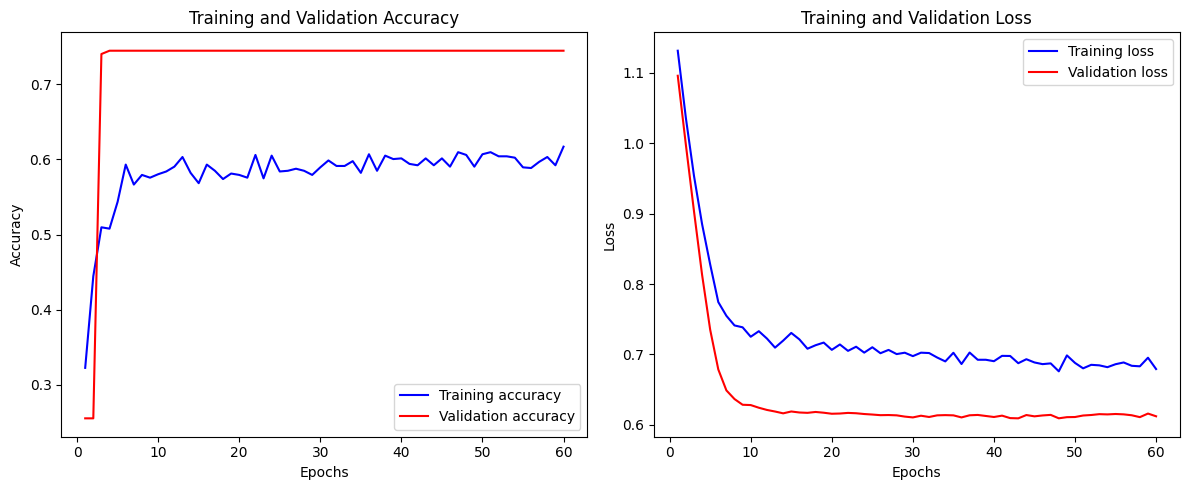

In [929]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_1.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [930]:
epochs_metrics_2 = model2.fit(X_train_lift[train_indices[1]], y2[train_indices[1]],  validation_data=(X_train_lift[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 45)

Epoch 1/45
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 40ms/step - accuracy: 0.3352 - loss: 1.1102 - val_accuracy: 0.8086 - val_loss: 1.0555
Epoch 2/45
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4237 - loss: 1.0484 - val_accuracy: 0.8242 - val_loss: 0.9920
Epoch 3/45
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5047 - loss: 0.9810 - val_accuracy: 0.7695 - val_loss: 0.9326
Epoch 4/45
67/67 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.5358 - loss: 0.9168 - val_accuracy: 0.8242 - val_loss: 0.8616
Epoch 5/45
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.5254 - loss: 0.8592 - val_accuracy: 0.8242 - val_loss: 0.7856
Epoch 6/45
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5339 - loss: 0.8187 - val_accuracy: 0.8242 - val_loss: 0.7476
Epoch 7/45
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4887 - loss: 0.8197 - val_accuracy: 0.8242 - val_loss: 0.7181
Epoch 8/45
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5169 - loss: 0.7945 - val_accuracy: 0.8242 - v

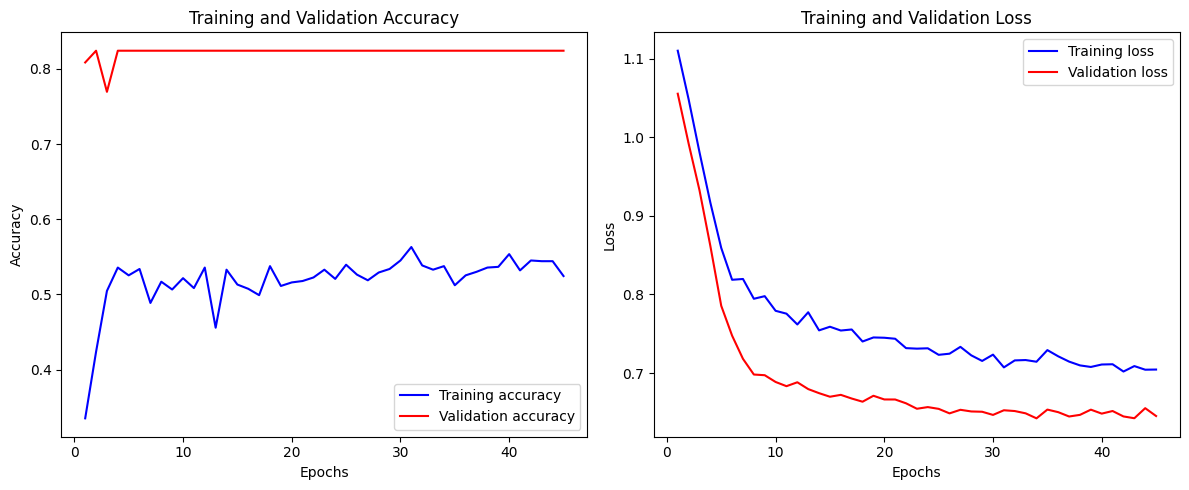

In [1061]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_2.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [933]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model2.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍速度流暢度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
整體測試集準確度 (Overall Test Accuracy): 0.6000

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000       150
     1分 (普通)     0.6000    1.0000    0.7500       225

    accuracy                         0.6000       375
   macro avg     0.3000    0.5000    0.3750       375
weighted avg     0.3600    0.6000    0.4500       375



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [934]:
epochs_metrics_3 = model3.fit(X_train_lift[train_indices[2]], y3[train_indices[2]],  validation_data=(X_train_lift[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 30)

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - accuracy: 0.3944 - loss: 1.0862 - val_accuracy: 0.6049 - val_loss: 1.0134
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4772 - loss: 1.0321 - val_accuracy: 0.6049 - val_loss: 0.9701
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5200 - loss: 0.9992 - val_accuracy: 0.6049 - val_loss: 0.9300
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.5535 - loss: 0.9569 - val_accuracy: 0.6049 - val_loss: 0.8898
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5526 - loss: 0.9196 - val_accuracy: 0.6049 - val_loss: 0.8510
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5628 - loss: 0.8845 - val_accuracy: 0.6049 - val_loss: 0.8175
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5535 - loss: 0.8638 - val_accuracy: 0.6049 - val_loss: 0.7902
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.5330 - loss: 0.8401 - val_accuracy: 0.6049 - v

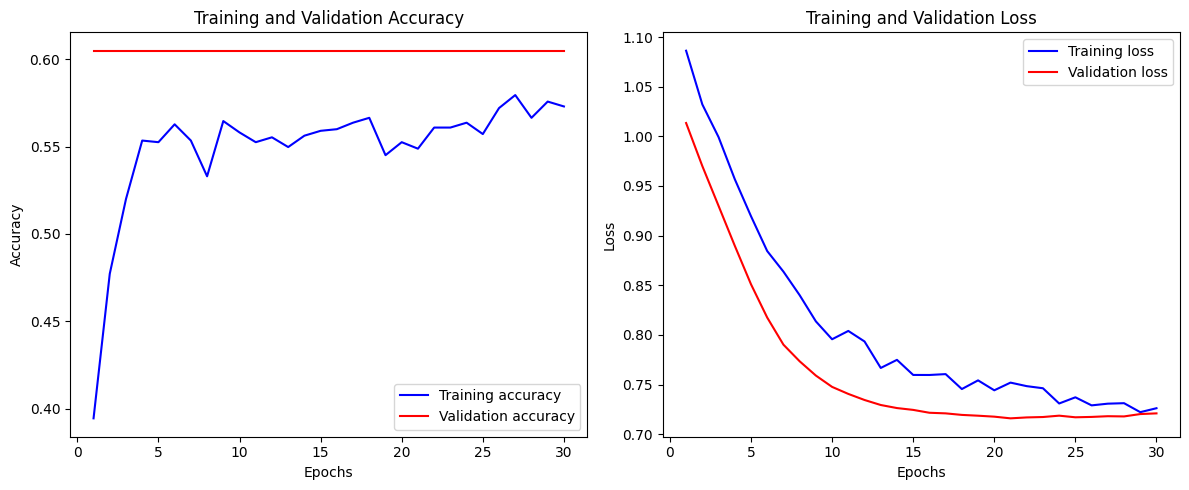

In [935]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_3.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [937]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model3.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['手腕轉動時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
整體測試集準確度 (Overall Test Accuracy): 0.6400

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.6400    1.0000    0.7805       240
     1分 (普通)     0.0000    0.0000    0.0000       135

    accuracy                         0.6400       375
   macro avg     0.3200    0.5000    0.3902       375
weighted avg     0.4096    0.6400    0.4995       375



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [938]:
epochs_metrics_4 = model4.fit(X_train_lift[train_indices[3]], y4[train_indices[3]],  validation_data=(X_train_lift[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 30)

Epoch 1/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - accuracy: 0.4432 - loss: 1.0968 - val_accuracy: 0.8074 - val_loss: 0.9557
Epoch 2/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.5754 - loss: 1.0141 - val_accuracy: 0.8074 - val_loss: 0.8809
Epoch 3/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5764 - loss: 0.9622 - val_accuracy: 0.8074 - val_loss: 0.8166
Epoch 4/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5996 - loss: 0.8953 - val_accuracy: 0.8074 - val_loss: 0.7508
Epoch 5/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.5577 - loss: 0.8429 - val_accuracy: 0.8074 - val_loss: 0.6971
Epoch 6/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 49ms/step - accuracy: 0.5708 - loss: 0.8085 - val_accuracy: 0.8074 - val_loss: 0.6667
Epoch 7/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - accuracy: 0.5605 - loss: 0.8012 - val_accuracy: 0.8074 - val_loss: 0.6504
Epoch 8/30
68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 50ms/step - accuracy: 0.5549 - loss: 0.7908 - val_accuracy: 0.8074 - v

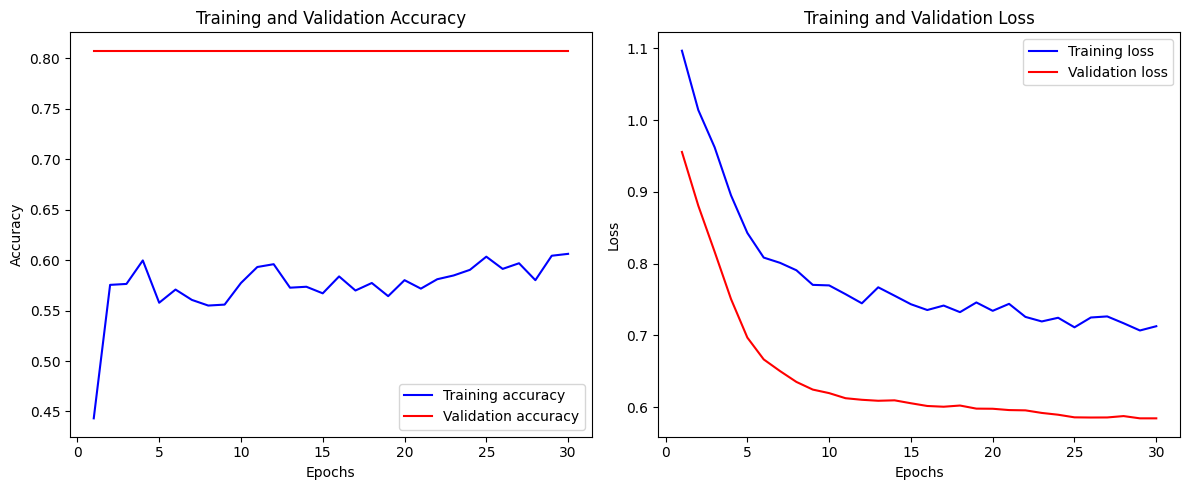

In [939]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_4.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [941]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model4.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['擊球時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
整體測試集準確度 (Overall Test Accuracy): 0.6027

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000       149
     1分 (普通)     0.6027    1.0000    0.7521       226

    accuracy                         0.6027       375
   macro avg     0.3013    0.5000    0.3760       375
weighted avg     0.3632    0.6027    0.4533       375



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [942]:
epochs_metrics_5 = model5.fit(X_train_lift[train_indices[4]], y4[train_indices[4]],  validation_data=(X_train_lift[val_indices[4]], y4[val_indices[4]]), batch_size = 16, epochs = 50)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - accuracy: 0.5401 - loss: 1.0589 - val_accuracy: 0.7342 - val_loss: 0.9889
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5849 - loss: 1.0063 - val_accuracy: 0.7342 - val_loss: 0.9364
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5812 - loss: 0.9608 - val_accuracy: 0.7342 - val_loss: 0.8774
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.6022 - loss: 0.8950 - val_accuracy: 0.7342 - val_loss: 0.8083
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 36ms/step - accuracy: 0.5830 - loss: 0.8707 - val_accuracy: 0.7342 - val_loss: 0.7501
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - accuracy: 0.5839 - loss: 0.8240 - val_accuracy: 0.7342 - val_loss: 0.6978
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.5821 - loss: 0.7983 - val_accuracy: 0.7342 - val_loss: 0.6739
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.5703 - loss: 0.7971 - val_accuracy: 0.7342 - v

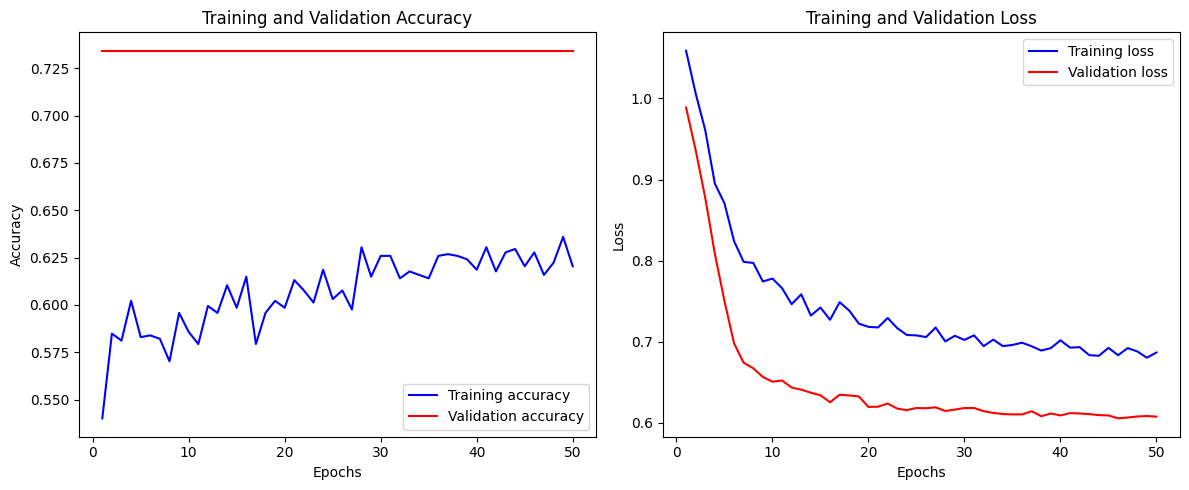

In [943]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_5.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [1055]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model5.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['擊球位置正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3979

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        49
     1分 (普通)     0.3979    1.0000    0.5693       150
      2分 (好)     0.0000    0.0000    0.0000       178

    accuracy                         0.3979       377
   macro avg     0.1326    0.3333    0.1898       377
weighted avg     0.1583    0.3979    0.2265       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

# CNN

In [85]:
model6 =  create_model_2(6)
epochs_metrics_6 = model6.fit(X_train_lift[train_indices[0]], y1[train_indices[0]],  validation_data=(X_train_lift[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 30)

Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_17 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_17 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_17 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3807 - loss: 1.0956 - val_accuracy: 0.5600 - val_loss: 1.0411
Epoch 2/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4091 - loss: 1.0875 - val_accuracy: 0.5673 - val_loss: 1.0354
Epoch 3/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4839 - loss: 1.0798 - val_accuracy: 0.5745 - val_loss: 1.0535
Epoch 4/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4744 - loss: 1.0749 - val_accuracy: 0.5636 - val_loss: 1.0566
Epoch 5/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4811 - loss: 1.0684 - val_accuracy: 0.6036 - val_loss: 1.0487
Epoch 6/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5047 - loss: 1.0616 - val_accuracy: 0.6109 - val_loss: 1.0514
Epoch 7/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4915 - loss: 1.0553 - val_accuracy: 0.5527 - val_loss: 1.0522
Epoch 8/30
66/66 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5133 - loss: 1.0501 - val_accuracy: 0.5382 - val_loss

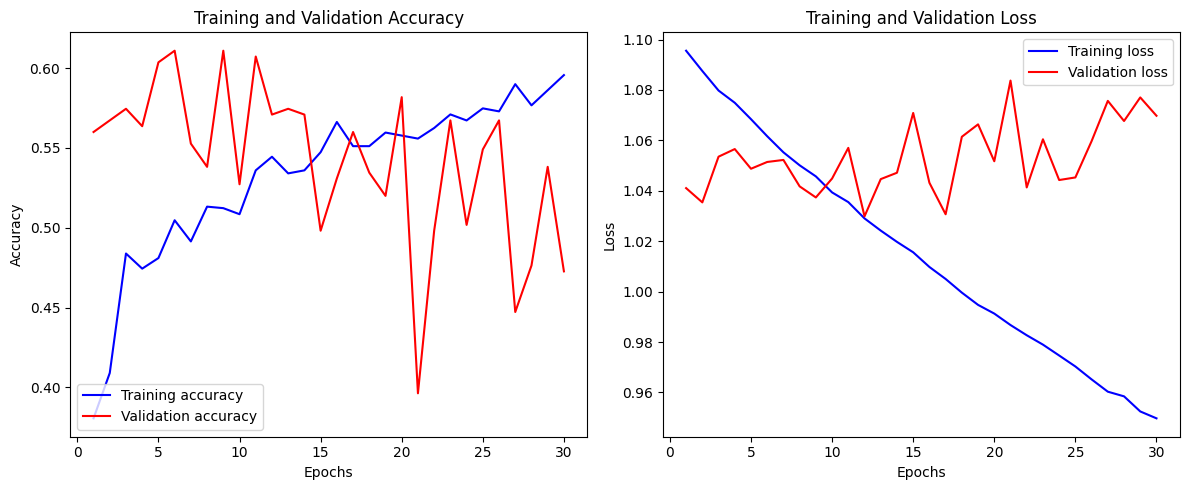

In [87]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_6.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [88]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model6.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍軌跡正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3591

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.1739    0.2553    0.2069        47
     1分 (普通)     0.2950    0.2733    0.2837       150
      2分 (好)     0.5000    0.4667    0.4828       165

    accuracy                         0.3591       362
   macro avg     0.3230    0.3318    0.3245       362
weighted avg     0.3727    0.3591    0.3645       362



In [95]:
model7 =  create_model_2(6)
epochs_metrics_7 = model7.fit(X_train_lift[train_indices[1]], y2[train_indices[1]],  validation_data=(X_train_lift[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 60)

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_19 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_19 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_19 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.3756 - loss: 1.1038 - val_accuracy: 0.3274 - val_loss: 1.2092
Epoch 2/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4317 - loss: 1.0369 - val_accuracy: 0.3186 - val_loss: 1.2759
Epoch 3/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4253 - loss: 1.0342 - val_accuracy: 0.2788 - val_loss: 1.2876
Epoch 4/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4652 - loss: 1.0298 - val_accuracy: 0.2257 - val_loss: 1.2861
Epoch 5/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4724 - loss: 1.0236 - val_accuracy: 0.2655 - val_loss: 1.2833
Epoch 6/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5339 - loss: 1.0125 - val_accuracy: 0.3186 - val_loss: 1.2581
Epoch 7/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5475 - loss: 1.0020 - val_accuracy: 0.3496 - val_loss: 1.2340
Epoch 8/60
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5873 - loss: 0.9943 - val_accuracy: 0.3407 - val_loss

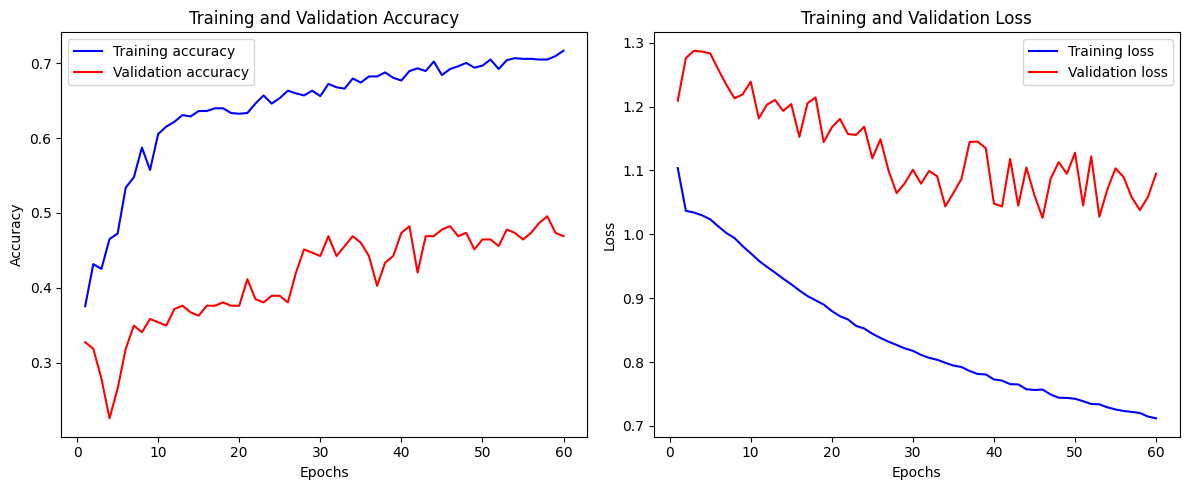

In [96]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_7.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [97]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model7.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍速度流暢度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
整體測試集準確度 (Overall Test Accuracy): 0.4779

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.7059    0.2000    0.3117        60
     1分 (普通)     0.4438    0.5435    0.4886       138
          2分     0.4886    0.5244    0.5059       164

    accuracy                         0.4779       362
   macro avg     0.5461    0.4226    0.4354       362
weighted avg     0.5075    0.4779    0.4671       362



In [139]:
model8 =  create_model_2(6)
epochs_metrics_8 = model8.fit(X_train_lift[train_indices[2]], y3[train_indices[2]],  validation_data=(X_train_lift[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 10)

Model: "sequential_33"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_33 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_33 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_33 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.3684 - loss: 1.1059 - val_accuracy: 0.6330 - val_loss: 1.0054
Epoch 2/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4537 - loss: 1.0633 - val_accuracy: 0.6330 - val_loss: 1.0070
Epoch 3/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4546 - loss: 1.0569 - val_accuracy: 0.6330 - val_loss: 1.0020
Epoch 4/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4483 - loss: 1.0432 - val_accuracy: 0.6376 - val_loss: 0.9788
Epoch 5/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4546 - loss: 1.0314 - val_accuracy: 0.5550 - val_loss: 1.0223
Epoch 6/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4600 - loss: 1.0216 - val_accuracy: 0.6239 - val_loss: 1.0028
Epoch 7/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4555 - loss: 1.0084 - val_accuracy: 0.5826 - val_loss: 1.0262
Epoch 8/10
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4726 - loss: 0.9990 - val_accuracy: 0.6239 - val_loss

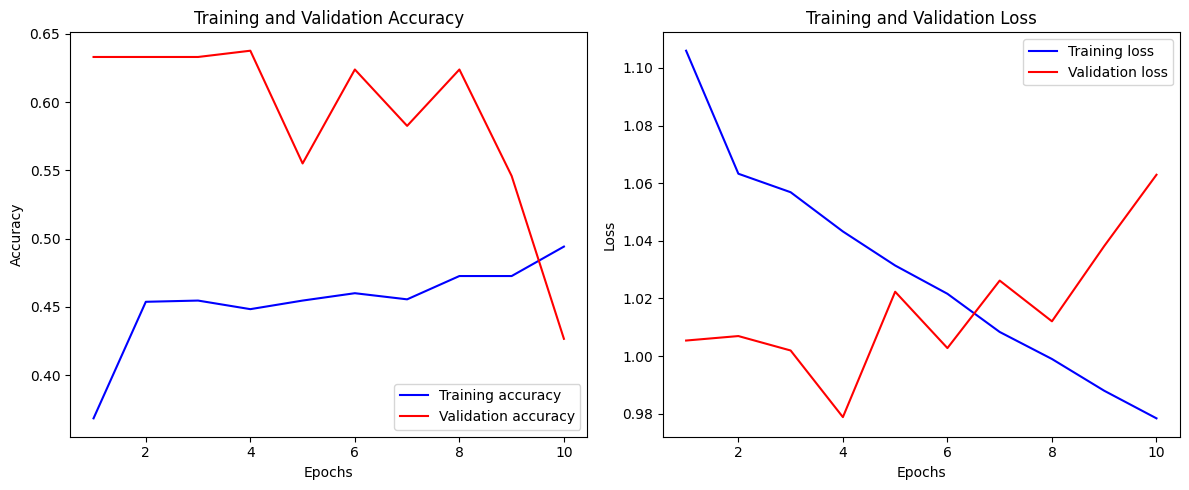

In [140]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_8.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [141]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model8.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['手腕轉動時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
整體測試集準確度 (Overall Test Accuracy): 0.4282

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.3778    0.1417    0.2061       120
     1分 (普通)     0.4481    0.8214    0.5798       168
          2分     0.0000    0.0000    0.0000        74

    accuracy                         0.4282       362
   macro avg     0.2753    0.3210    0.2620       362
weighted avg     0.3332    0.4282    0.3374       362



In [122]:
model9 =  create_model_2(6)
epochs_metrics_9 = model9.fit(X_train_lift[train_indices[3]], y4[train_indices[3]],  validation_data=(X_train_lift[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 30)

Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_28 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_28 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_28 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.5018 - loss: 1.0036 - val_accuracy: 0.5771 - val_loss: 0.9682
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5471 - loss: 0.9469 - val_accuracy: 0.5903 - val_loss: 0.9948
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5534 - loss: 0.9397 - val_accuracy: 0.5859 - val_loss: 0.9823
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5489 - loss: 0.9319 - val_accuracy: 0.6256 - val_loss: 0.9935
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5507 - loss: 0.9257 - val_accuracy: 0.5859 - val_loss: 0.9839
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5525 - loss: 0.9166 - val_accuracy: 0.6300 - val_loss: 0.9861
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5679 - loss: 0.9109 - val_accuracy: 0.6432 - val_loss: 0.9838
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.5761 - loss: 0.9030 - val_accuracy: 0.6608 - val_loss

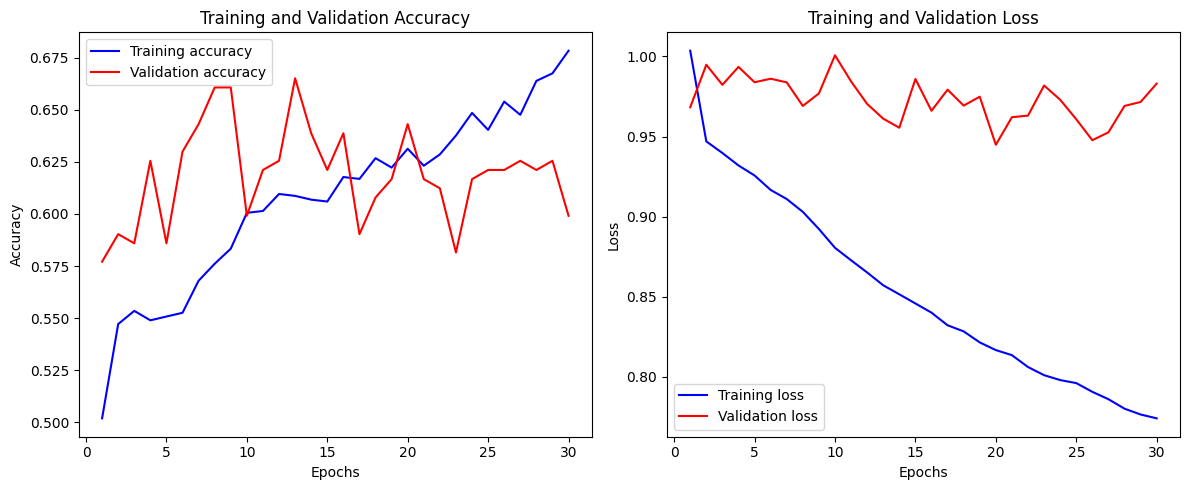

In [124]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_9.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [125]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model9.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['擊球時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
整體測試集準確度 (Overall Test Accuracy): 0.6768

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        47
     1分 (普通)     0.7627    0.8531    0.8054       211
          2分     0.5159    0.6250    0.5652       104

    accuracy                         0.6768       362
   macro avg     0.4262    0.4927    0.4569       362
weighted avg     0.5928    0.6768    0.6318       362



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [136]:
model10 =  create_model_2(6)
epochs_metrics_10 = model10.fit(X_train_lift[train_indices[4]], y5[train_indices[4]],  validation_data=(X_train_lift[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 20)

Model: "sequential_32"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_32 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_32 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_32 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 2,803 (10.95 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4281 - loss: 1.0555 - val_accuracy: 0.6239 - val_loss: 0.9385
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4452 - loss: 1.0420 - val_accuracy: 0.6239 - val_loss: 0.9464
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4615 - loss: 1.0370 - val_accuracy: 0.6239 - val_loss: 0.9532
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4796 - loss: 1.0318 - val_accuracy: 0.6239 - val_loss: 0.9342
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.4778 - loss: 1.0269 - val_accuracy: 0.6239 - val_loss: 0.9301
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4778 - loss: 1.0218 - val_accuracy: 0.6726 - val_loss: 0.9273
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.4950 - loss: 1.0169 - val_accuracy: 0.6460 - val_loss: 0.9076
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.4914 - loss: 1.0130 - val_accuracy: 0.7168 - val_loss

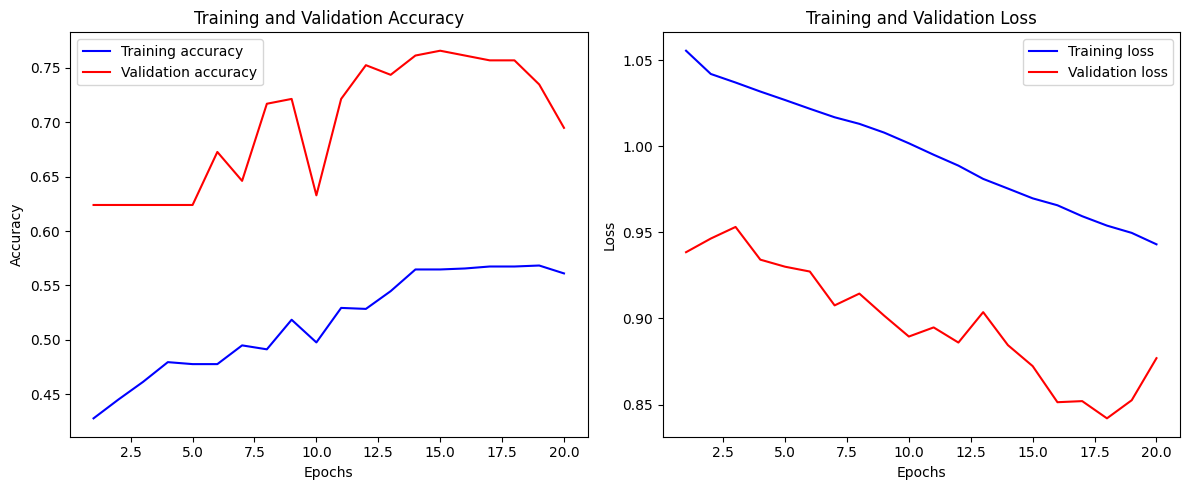

In [137]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_10.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [138]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model10.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['擊球位置正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分(好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step
整體測試集準確度 (Overall Test Accuracy): 0.4613

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        77
     1分 (普通)     0.5975    0.7956    0.6825       181
       2分(好)     0.1901    0.2212    0.2044       104

    accuracy                         0.4613       362
   macro avg     0.2625    0.3389    0.2956       362
weighted avg     0.3534    0.4613    0.4000       362



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

# CNN + LSTM

In [966]:
model11 =  create_model_3(6)
model12 =  create_model_3(6)
model13 =  create_model_3(6)
model14 =  create_model_3(6)
model15 =  create_model_3(6)

Model: "sequential_221"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_75 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_75 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_110 (LSTM)                 │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_110 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_224 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,139 (12.26 KB)

 Trainable params: 3,139 (12.26 KB)

 Non-trainable params: 0 (0.00 B)

...

Model: "sequential_225"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_79 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_79 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_114 (LSTM)                 │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_114 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_228 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,139 (12.26 KB)

 Trainable params: 3,139 (12.26 KB)

 Non-trainable params: 0 (0.00 B)

In [967]:
epochs_metrics_11 = model11.fit(X_train_lift[train_indices[0]], y1[train_indices[0]],  validation_data=(X_train_lift[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 30)

Epoch 1/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.4097 - loss: 1.2915 - val_accuracy: 0.7445 - val_loss: 1.2266
Epoch 2/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5270 - loss: 1.2126 - val_accuracy: 0.7445 - val_loss: 1.1446
Epoch 3/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5839 - loss: 1.1389 - val_accuracy: 0.7445 - val_loss: 1.0762
Epoch 4/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5830 - loss: 1.0871 - val_accuracy: 0.7445 - val_loss: 1.0182
Epoch 5/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5692 - loss: 1.0498 - val_accuracy: 0.7445 - val_loss: 0.9673
Epoch 6/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5665 - loss: 0.9956 - val_accuracy: 0.7445 - val_loss: 0.9171
Epoch 7/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5866 - loss: 0.9628 - val_accuracy: 0.7445 - val_loss: 0.8803
Epoch 8/30
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5820 - loss: 0.9370 - val_accuracy: 0.7445 - v

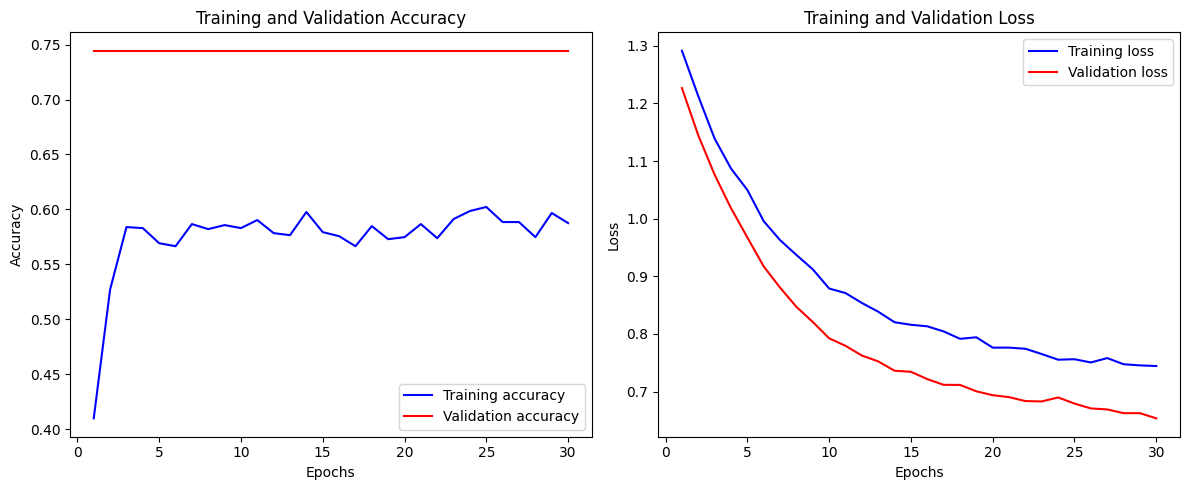

In [968]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_11.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [1056]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model11.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍軌跡正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)','2分'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
整體測試集準確度 (Overall Test Accuracy): 0.4775

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        17
     1分 (普通)     0.4775    1.0000    0.6463       180
          2分     0.0000    0.0000    0.0000       180

    accuracy                         0.4775       377
   macro avg     0.1592    0.3333    0.2154       377
weighted avg     0.2280    0.4775    0.3086       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [971]:
epochs_metrics_12 = model12.fit(X_train_lift[train_indices[1]], y2[train_indices[1]],  validation_data=(X_train_lift[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 30)

Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5047 - loss: 1.2534 - val_accuracy: 0.8242 - val_loss: 1.1449
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5527 - loss: 1.1554 - val_accuracy: 0.8242 - val_loss: 1.0578
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5480 - loss: 1.0864 - val_accuracy: 0.8242 - val_loss: 0.9938
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5245 - loss: 1.0459 - val_accuracy: 0.8242 - val_loss: 0.9490
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5320 - loss: 1.0104 - val_accuracy: 0.8242 - val_loss: 0.9144
Epoch 6/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5395 - loss: 0.9760 - val_accuracy: 0.8242 - val_loss: 0.8949
Epoch 7/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5443 - loss: 0.9586 - val_accuracy: 0.8242 - val_loss: 0.8751
Epoch 8/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.5226 - loss: 0.9422 - val_accuracy: 0.8242 - v

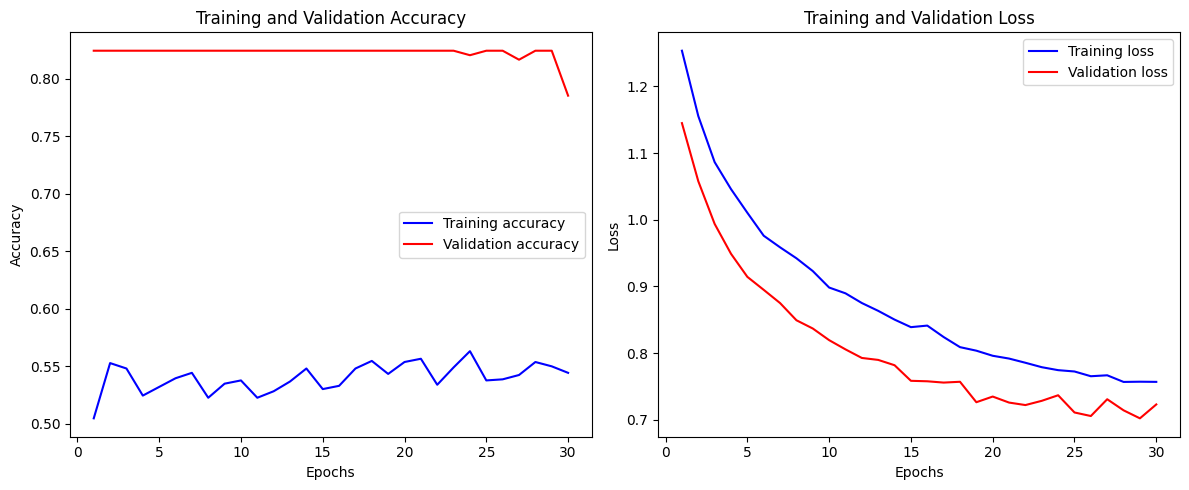

In [972]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_12.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [973]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model12.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍速度流暢度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
整體測試集準確度 (Overall Test Accuracy): 0.6000

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------


ValueError: Number of classes, 2, does not match size of target_names, 3. Try specifying the labels parameter

In [529]:
epochs_metrics_13 = model13.fit(X_train_lift[train_indices[2]], y3[train_indices[2]],  validation_data=(X_train_lift[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 32)

Epoch 1/32
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.3642 - loss: 1.3615 - val_accuracy: 0.6912 - val_loss: 1.2107
Epoch 2/32
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4173 - loss: 1.3202 - val_accuracy: 0.6912 - val_loss: 1.1878
Epoch 3/32
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4406 - loss: 1.2977 - val_accuracy: 0.6912 - val_loss: 1.1809
Epoch 4/32
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4388 - loss: 1.2794 - val_accuracy: 0.6912 - val_loss: 1.1617
Epoch 5/32
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4406 - loss: 1.2645 - val_accuracy: 0.6912 - val_loss: 1.1554
Epoch 6/32
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4388 - loss: 1.2501 - val_accuracy: 0.6912 - val_loss: 1.1385
Epoch 7/32
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.4397 - loss: 1.2355 - val_accuracy: 0.6912 - val_loss: 1.1279
Epoch 8/32
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.4397 - loss: 1.2243 - val_accuracy: 0.6912 - v

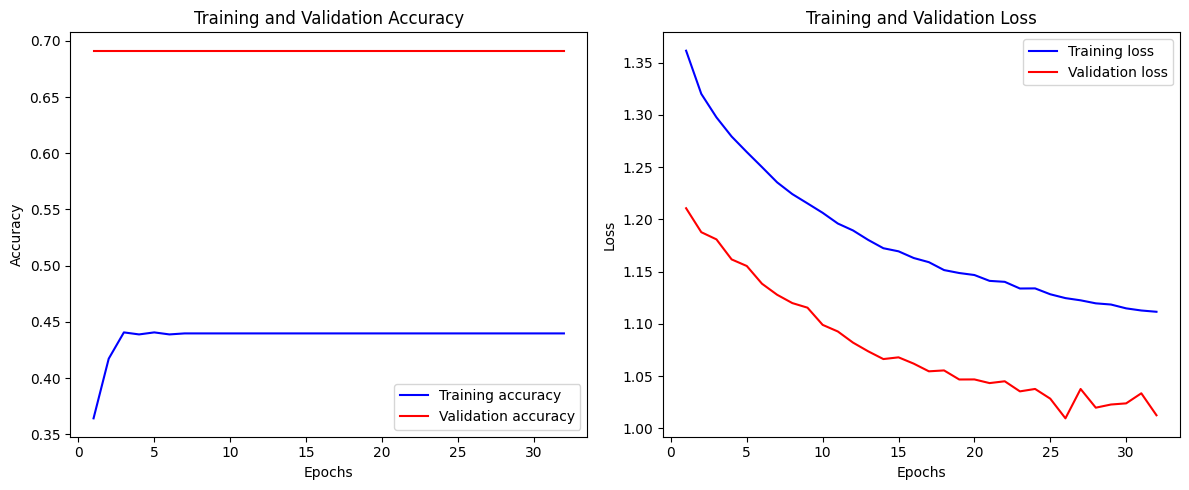

In [530]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_13.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [531]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model13.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['手腕轉動時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
整體測試集準確度 (Overall Test Accuracy): 0.4377

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        62
     1分 (普通)     0.4377    1.0000    0.6089       165
      2分 (好)     0.0000    0.0000    0.0000       150

    accuracy                         0.4377       377
   macro avg     0.1459    0.3333    0.2030       377
weighted avg     0.1916    0.4377    0.2665       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [532]:
epochs_metrics_14 = model14.fit(X_train_lift[train_indices[3]], y4[train_indices[3]],  validation_data=(X_train_lift[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 32)

Epoch 1/32
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.4580 - loss: 1.3143 - val_accuracy: 0.8648 - val_loss: 1.1283
Epoch 2/32
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4646 - loss: 1.2724 - val_accuracy: 0.8648 - val_loss: 1.0820
Epoch 3/32
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4580 - loss: 1.2439 - val_accuracy: 0.8648 - val_loss: 1.0597
Epoch 4/32
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4664 - loss: 1.2192 - val_accuracy: 0.8648 - val_loss: 1.0454
Epoch 5/32
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4683 - loss: 1.2026 - val_accuracy: 0.8648 - val_loss: 1.0372
Epoch 6/32
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4646 - loss: 1.1910 - val_accuracy: 0.8648 - val_loss: 1.0233
Epoch 7/32
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.4655 - loss: 1.1742 - val_accuracy: 0.8648 - val_loss: 1.0138
Epoch 8/32
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.4655 - loss: 1.1551 - val_accuracy: 0.8648 - v

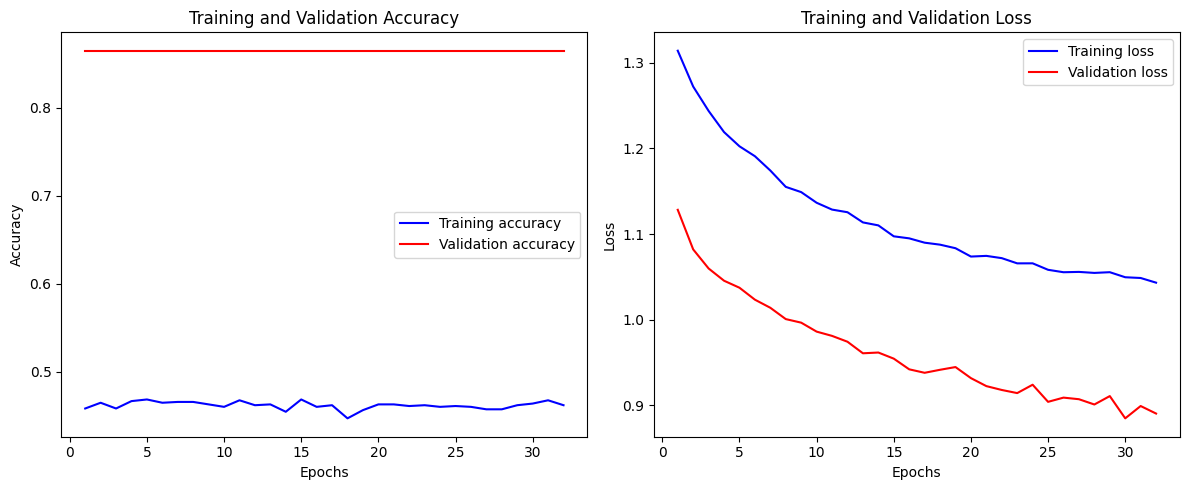

In [533]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_14.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [1057]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model14.predict(X_train_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['擊球時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

42/42 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


ValueError: Found input variables with inconsistent numbers of samples: [377, 1316]

In [544]:
epochs_metrics_15 = model15.fit(X_train_lift[train_indices[4]], y5[train_indices[4]],  validation_data=(X_train_lift[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 50)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.2857 - loss: 1.3888 - val_accuracy: 0.2000 - val_loss: 1.3636
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4801 - loss: 1.3149 - val_accuracy: 0.2238 - val_loss: 1.3889
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5235 - loss: 1.2699 - val_accuracy: 0.2238 - val_loss: 1.4150
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5280 - loss: 1.2530 - val_accuracy: 0.2238 - val_loss: 1.4033
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.5271 - loss: 1.2374 - val_accuracy: 0.2238 - val_loss: 1.3721
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.5280 - loss: 1.2214 - val_accuracy: 0.2238 - val_loss: 1.3595
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.5280 - loss: 1.2120 - val_accuracy: 0.2238 - val_loss: 1.3758
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - accuracy: 0.5289 - loss: 1.2008 - val_accuracy: 0.2238 - v

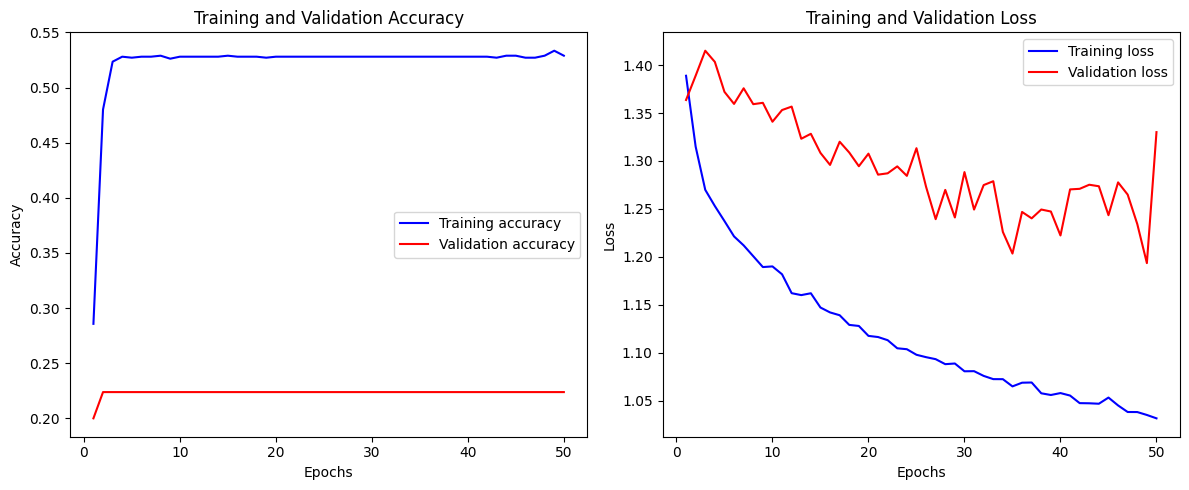

In [545]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = epochs_metrics_15.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [ ]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = model15.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['擊球位置正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3979

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        49
     1分 (普通)     0.3979    1.0000    0.5693       150
      2分 (好)     0.0000    0.0000    0.0000       178

    accuracy                         0.3979       377
   macro avg     0.1326    0.3333    0.1898       377
weighted avg     0.1583    0.3979    0.2265       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

# Transfer Learning

In [1062]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/lstm_base_model1.keras")

lstm_transfer_model1 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in lstm_transfer_model1.layers:
    layer.trainable=False
lstm_transfer_model1.add(Dense(3, activation='softmax'))

lstm_transfer_model1.build(input_shape=old_model.input_shape)
lstm_transfer_model1.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_transfer_model1.summary()


Model: "sequential_240"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_40 (LSTM)                  │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_40 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_243 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:

lstm_transfer_epochs_metrics_1 = lstm_transfer_model1.fit(X_train_lift[train_indices[0]], y1[train_indices[0]],  validation_data=(X_train_lift[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 60)

Epoch 1/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - accuracy: 0.2565 - loss: 1.1734 - val_accuracy: 0.1557 - val_loss: 1.2835
Epoch 2/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2621 - loss: 1.1655 - val_accuracy: 0.1557 - val_loss: 1.2713
Epoch 3/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.2603 - loss: 1.1587 - val_accuracy: 0.1557 - val_loss: 1.2593
Epoch 4/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - accuracy: 0.2705 - loss: 1.1499 - val_accuracy: 0.1557 - val_loss: 1.2487
Epoch 5/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.2696 - loss: 1.1490 - val_accuracy: 0.1557 - val_loss: 1.2379
Epoch 6/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.2882 - loss: 1.1412 - val_accuracy: 0.1557 - val_loss: 1.2289
Epoch 7/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.2826 - loss: 1.1391 - val_accuracy: 0.1557 - val_loss: 1.2200
Epoch 8/60
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.3004 - loss: 1.1239 - val_accuracy: 0.1557 - v

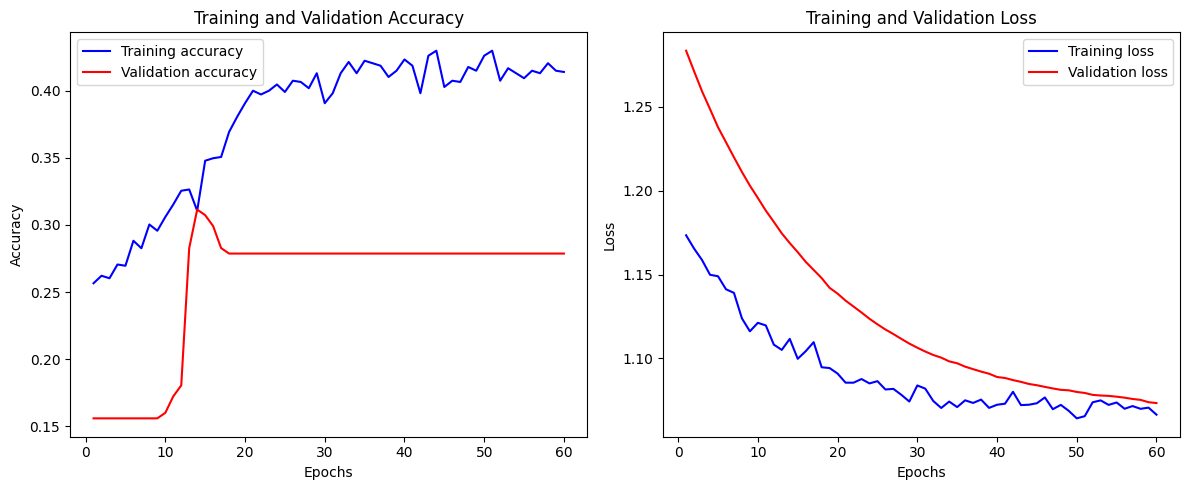

In [709]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = lstm_transfer_epochs_metrics_1.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [710]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = lstm_transfer_model1.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍軌跡正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
整體測試集準確度 (Overall Test Accuracy): 0.4695

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        17
     1分 (普通)     0.0000    0.0000    0.0000       180
      2分 (好)     0.4733    0.9833    0.6390       180

    accuracy                         0.4695       377
   macro avg     0.1578    0.3278    0.2130       377
weighted avg     0.2260    0.4695    0.3051       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [711]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/lstm_base_model2.keras")

lstm_transfer_model2 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in lstm_transfer_model2.layers:
    layer.trainable=False
lstm_transfer_model2.add(Dense(3, activation='softmax'))

lstm_transfer_model2.build(input_shape=old_model.input_shape)
lstm_transfer_model2.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_transfer_model2.summary()

Model: "sequential_168"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_41 (LSTM)                  │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_41 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_172 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 1,472 (5.75 KB)

In [ ]:
lstm_transfer_epochs_metrics_2 = lstm_transfer_model2.fit(X_train_lift[train_indices[1]], y2[train_indices[1]],  validation_data=(X_train_lift[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs = 50)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - accuracy: 0.3508 - loss: 1.1322 - val_accuracy: 0.3571 - val_loss: 1.1434
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 52ms/step - accuracy: 0.3490 - loss: 1.1149 - val_accuracy: 0.3571 - val_loss: 1.1140
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.3553 - loss: 1.1119 - val_accuracy: 0.3571 - val_loss: 1.0904
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.3608 - loss: 1.1049 - val_accuracy: 0.3571 - val_loss: 1.0759
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 60ms/step - accuracy: 0.3590 - loss: 1.1056 - val_accuracy: 0.3571 - val_loss: 1.0660
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 59ms/step - accuracy: 0.3635 - loss: 1.0960 - val_accuracy: 0.3571 - val_loss: 1.0586
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 61ms/step - accuracy: 0.3499 - loss: 1.1039 - val_accuracy: 0.3571 - val_loss: 1.0558
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - accuracy: 0.3689 - loss: 1.0911 - val_accuracy: 0.3571 - v

In [716]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = lstm_transfer_epochs_metrics_2.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

NameError: name 'lstm_transfer_epochs_metrics_2' is not defined

In [713]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = lstm_transfer_model1.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍速度流暢度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3899

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        62
     1分 (普通)     0.0000    0.0000    0.0000       165
      2分 (好)     0.3930    0.9800    0.5611       150

    accuracy                         0.3899       377
   macro avg     0.1310    0.3267    0.1870       377
weighted avg     0.1564    0.3899    0.2232       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [724]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/lstm_base_model3.keras")

lstm_transfer_model3 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in lstm_transfer_model3.layers:
    layer.trainable=False
lstm_transfer_model3.add(Dense(3, activation='softmax'))

lstm_transfer_model3.build(input_shape=old_model.input_shape)
lstm_transfer_model3.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_transfer_model3.summary()

Model: "sequential_171"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_47 (LSTM)                  │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_175 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 1,472 (5.75 KB)

In [725]:
lstm_transfer_epochs_metrics_3 = lstm_transfer_model3.fit(X_train_lift[train_indices[2]], y3[train_indices[2]],  validation_data=(X_train_lift[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 20)

Epoch 1/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - accuracy: 0.2770 - loss: 1.3822 - val_accuracy: 0.2402 - val_loss: 1.2370
Epoch 2/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.2761 - loss: 1.3700 - val_accuracy: 0.2402 - val_loss: 1.2048
Epoch 3/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.2752 - loss: 1.3161 - val_accuracy: 0.2402 - val_loss: 1.1756
Epoch 4/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.2779 - loss: 1.2877 - val_accuracy: 0.2402 - val_loss: 1.1486
Epoch 5/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 39ms/step - accuracy: 0.2806 - loss: 1.2736 - val_accuracy: 0.2402 - val_loss: 1.1252
Epoch 6/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.2788 - loss: 1.2590 - val_accuracy: 0.2402 - val_loss: 1.1020
Epoch 7/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.2833 - loss: 1.2324 - val_accuracy: 0.2402 - val_loss: 1.0817
Epoch 8/20
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.2869 - loss: 1.2226 - val_accuracy: 0.2402 - v

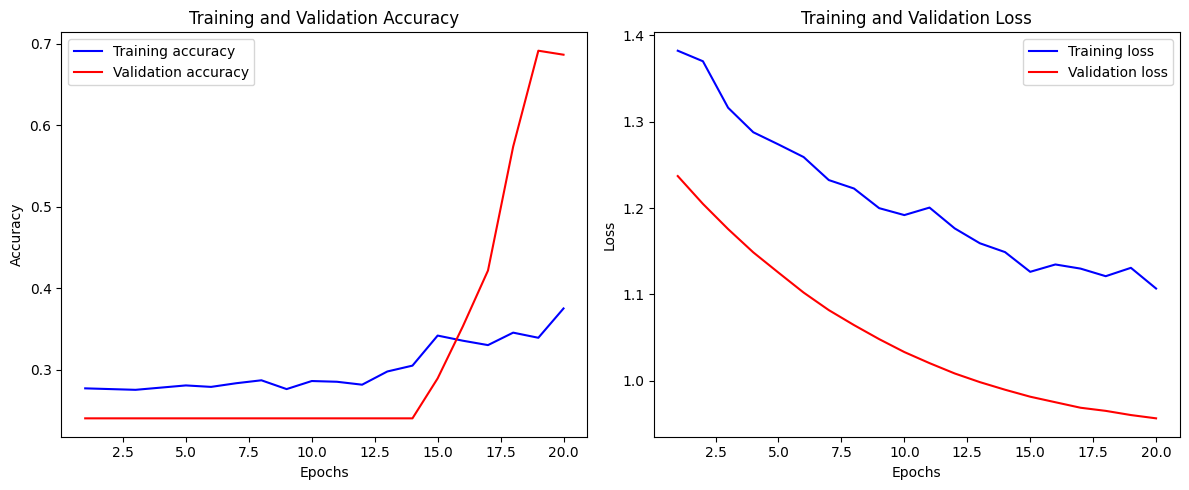

In [726]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = lstm_transfer_epochs_metrics_3.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [727]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = lstm_transfer_model3.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['手腕轉動時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3369

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0159    0.0161    0.0160        62
     1分 (普通)     0.4013    0.7636    0.5261       165
      2分 (好)     0.0000    0.0000    0.0000       150

    accuracy                         0.3369       377
   macro avg     0.1390    0.2599    0.1807       377
weighted avg     0.1782    0.3369    0.2329       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [735]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/lstm_base_model4.keras")

lstm_transfer_model4 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in lstm_transfer_model4.layers:
    layer.trainable=False
lstm_transfer_model4.add(Dense(3, activation='softmax'))

lstm_transfer_model4.build(input_shape=old_model.input_shape)
lstm_transfer_model4.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_transfer_model4.summary()

Model: "sequential_174"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_48 (LSTM)                  │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_178 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 1,472 (5.75 KB)

In [736]:
lstm_transfer_epochs_metrics_4 = lstm_transfer_model4.fit(X_train_lift[train_indices[3]], y4[train_indices[3]],  validation_data=(X_train_lift[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 50)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - accuracy: 0.3993 - loss: 1.0985 - val_accuracy: 0.8648 - val_loss: 0.8988
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4160 - loss: 1.0814 - val_accuracy: 0.8648 - val_loss: 0.8941
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.4132 - loss: 1.0700 - val_accuracy: 0.8648 - val_loss: 0.8904
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4151 - loss: 1.0675 - val_accuracy: 0.8648 - val_loss: 0.8899
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4291 - loss: 1.0649 - val_accuracy: 0.8648 - val_loss: 0.8874
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.4263 - loss: 1.0697 - val_accuracy: 0.8648 - val_loss: 0.8880
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.4254 - loss: 1.0700 - val_accuracy: 0.8648 - val_loss: 0.8863
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - accuracy: 0.4291 - loss: 1.0656 - val_accuracy: 0.8648 - v

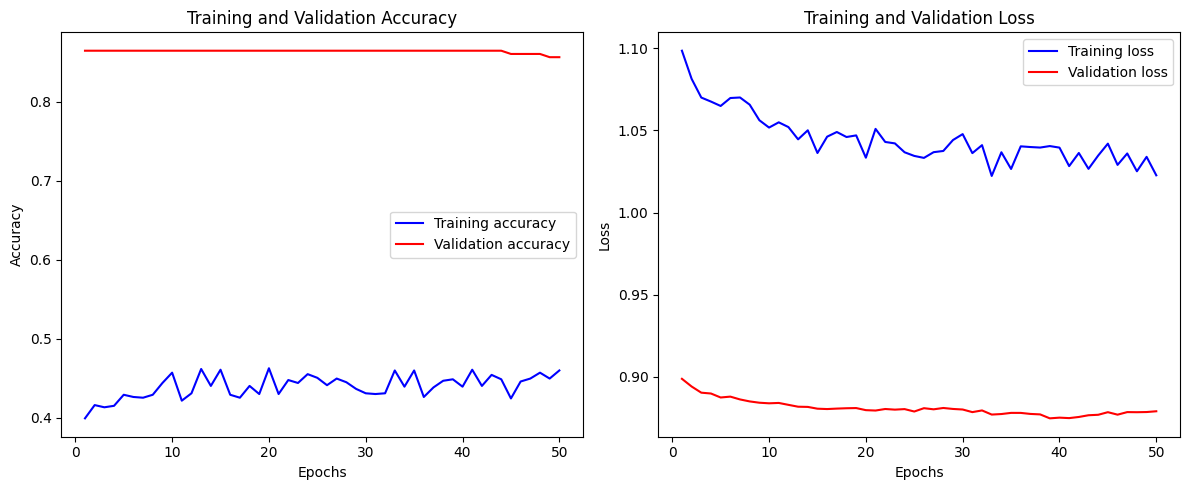

In [737]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = lstm_transfer_epochs_metrics_4.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [738]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = lstm_transfer_model4.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['擊球時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3846

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        79
     1分 (普通)     0.3371    1.0000    0.5043       118
      2分 (好)     1.0000    0.1500    0.2609       180

    accuracy                         0.3846       377
   macro avg     0.4457    0.3833    0.2550       377
weighted avg     0.5830    0.3846    0.2824       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [753]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/lstm_base_model5.keras")

lstm_transfer_model5 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in lstm_transfer_model5.layers:
    layer.trainable=False
lstm_transfer_model5.add(Dense(3, activation='softmax'))

lstm_transfer_model5.build(input_shape=old_model.input_shape)
lstm_transfer_model5.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
lstm_transfer_model5.summary()

Model: "sequential_180"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_49 (LSTM)                  │ (None, 16)             │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_184 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,523 (5.95 KB)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 1,472 (5.75 KB)

In [754]:
lstm_transfer_epochs_metrics_5 = lstm_transfer_model5.fit(X_train_lift[train_indices[4]], y5[train_indices[4]],  validation_data=(X_train_lift[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 50)

Epoch 1/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.2712 - loss: 1.2657 - val_accuracy: 0.6381 - val_loss: 0.9733
Epoch 2/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - accuracy: 0.2848 - loss: 1.2348 - val_accuracy: 0.6381 - val_loss: 0.9765
Epoch 3/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.2839 - loss: 1.2090 - val_accuracy: 0.6381 - val_loss: 0.9801
Epoch 4/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.2884 - loss: 1.1909 - val_accuracy: 0.6381 - val_loss: 0.9846
Epoch 5/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.3011 - loss: 1.1701 - val_accuracy: 0.6381 - val_loss: 0.9907
Epoch 6/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.3219 - loss: 1.1488 - val_accuracy: 0.6381 - val_loss: 0.9985
Epoch 7/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.3373 - loss: 1.1328 - val_accuracy: 0.6381 - val_loss: 1.0064
Epoch 8/50
70/70 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - accuracy: 0.3382 - loss: 1.1300 - val_accuracy: 0.6381 - v

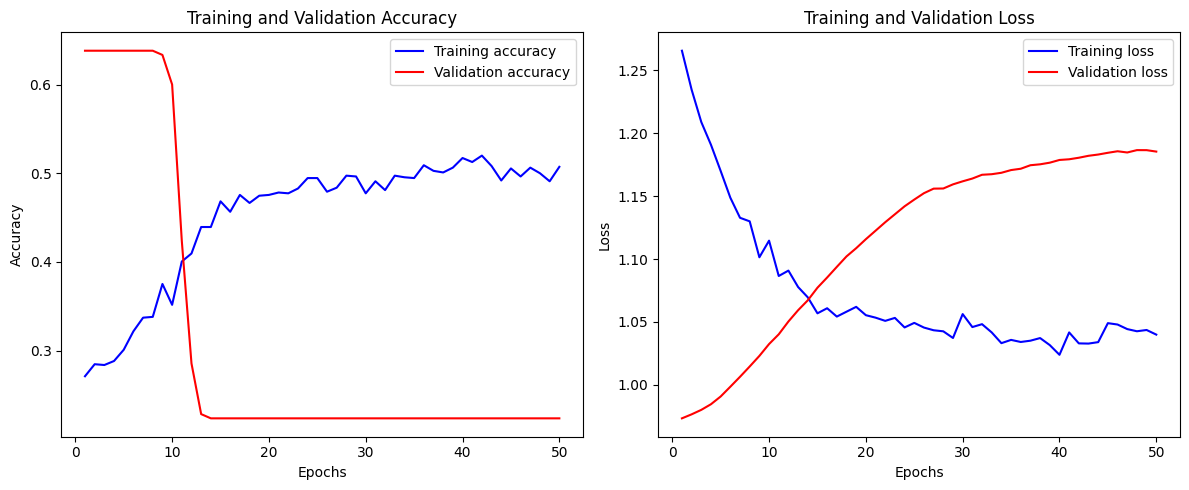

In [755]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = lstm_transfer_epochs_metrics_5.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [1034]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = lstm_transfer_model5.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['擊球位置正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3979

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        49
     1分 (普通)     0.3979    1.0000    0.5693       150
      2分 (好)     0.0000    0.0000    0.0000       178

    accuracy                         0.3979       377
   macro avg     0.1326    0.3333    0.1898       377
weighted avg     0.1583    0.3979    0.2265       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [376]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/cnn_base_model1.keras")

cnn_transfer_model1 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in cnn_transfer_model1.layers:
    layer.trainable=False
    
cnn_transfer_model1.add(Dense(3, activation='softmax'))

cnn_transfer_model1.build(input_shape=old_model.input_shape)
cnn_transfer_model1.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_transfer_model1.summary()

c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 10 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Model: "sequential_81"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_25 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_25 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_81 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 1,827 (7.14 KB)

 Non-trainable params: 976 (3.81 KB)

In [377]:
cnn_transfer_epochs_metrics_1 = cnn_transfer_model1.fit(X_train_lift[train_indices[0]], y1[train_indices[0]],  validation_data=(X_train_lift[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 10)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2129 - loss: 1.1420 - val_accuracy: 0.2179 - val_loss: 1.1296
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5012 - loss: 1.0291 - val_accuracy: 0.2682 - val_loss: 1.1630
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5170 - loss: 0.9875 - val_accuracy: 0.2402 - val_loss: 1.2171
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5377 - loss: 0.9706 - val_accuracy: 0.2570 - val_loss: 1.2458
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5620 - loss: 0.9619 - val_accuracy: 0.2682 - val_loss: 1.2706
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5572 - loss: 0.9557 - val_accuracy: 0.2346 - val_loss: 1.2904
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5730 - loss: 0.9503 - val_accuracy: 0.2458 - val_loss: 1.3006
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5912 - loss: 0.9450 - val_accuracy: 0.2682 - val_loss:

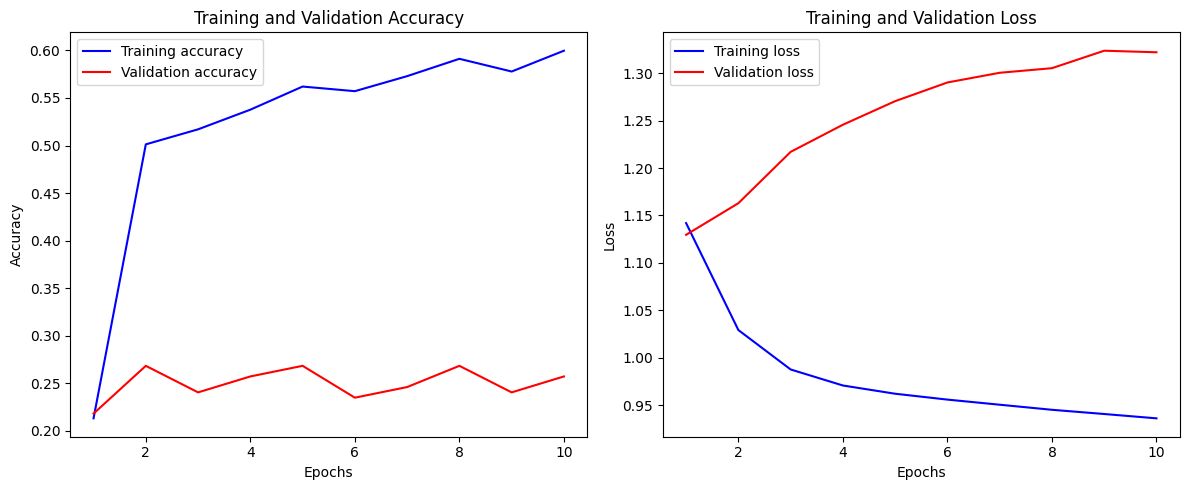

In [378]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_transfer_epochs_metrics_1.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [380]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_transfer_model1.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍軌跡正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
整體測試集準確度 (Overall Test Accuracy): 0.2110

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        79
     1分 (普通)     0.2722    0.2416    0.2560       356
      2分 (好)     0.1596    0.2335    0.1896       257

    accuracy                         0.2110       692
   macro avg     0.1439    0.1583    0.1485       692
weighted avg     0.1993    0.2110    0.2021       692



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [393]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/cnn_base_model2.keras")

cnn_transfer_model2 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in cnn_transfer_model2.layers:
    layer.trainable=False
cnn_transfer_model2.add(Dense(3, activation='softmax'))

cnn_transfer_model2.build(input_shape=old_model.input_shape)
cnn_transfer_model2.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_transfer_model2.summary()

Model: "sequential_85"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_26 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_26 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_16 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_85 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 1,827 (7.14 KB)

 Non-trainable params: 976 (3.81 KB)

In [394]:
cnn_transfer_epochs_metrics_2 = cnn_transfer_model2.fit(X_train_lift[train_indices[1]], y2[train_indices[1]],  validation_data=(X_train_lift[val_indices[1]], y2[val_indices[1]]), batch_size = 16, epochs =30)

Epoch 1/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.2801 - loss: 1.2334 - val_accuracy: 0.2778 - val_loss: 1.1439
Epoch 2/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4202 - loss: 1.0453 - val_accuracy: 0.2944 - val_loss: 1.2343
Epoch 3/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4458 - loss: 1.0279 - val_accuracy: 0.2778 - val_loss: 1.2655
Epoch 4/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4714 - loss: 1.0183 - val_accuracy: 0.2444 - val_loss: 1.2557
Epoch 5/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4787 - loss: 1.0096 - val_accuracy: 0.2722 - val_loss: 1.2779
Epoch 6/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4860 - loss: 1.0011 - val_accuracy: 0.2278 - val_loss: 1.2800
Epoch 7/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4933 - loss: 0.9932 - val_accuracy: 0.2389 - val_loss: 1.2803
Epoch 8/30
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4909 - loss: 0.9882 - val_accuracy: 0.2167 - val_loss:

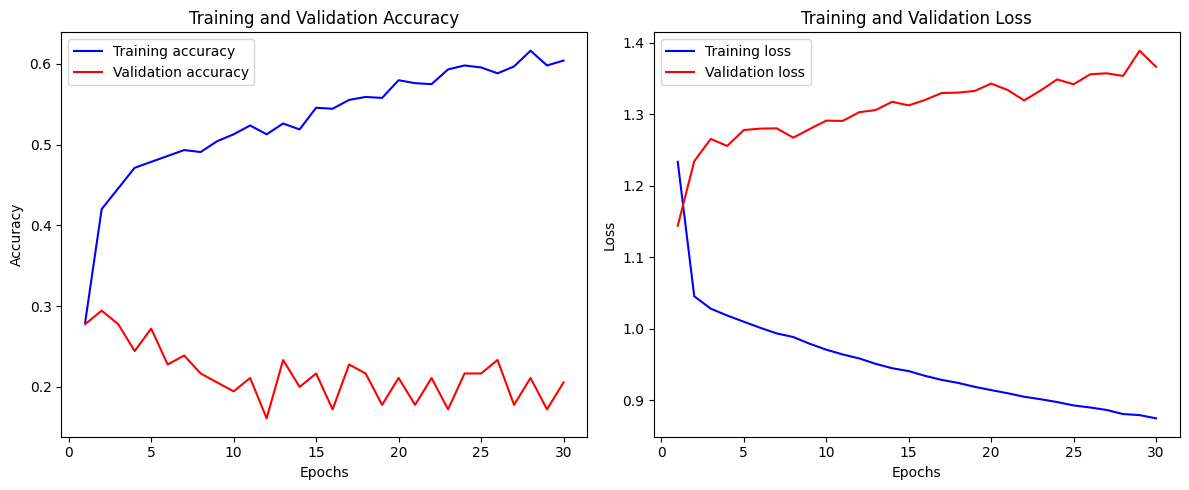

In [395]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_transfer_epochs_metrics_2.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [396]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_transfer_model2.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍速度流暢度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3815

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000       120
     1分 (普通)     0.5243    0.1709    0.2578       316
      2分 (好)     0.3571    0.8203    0.4976       256

    accuracy                         0.3815       692
   macro avg     0.2938    0.3304    0.2518       692
weighted avg     0.3715    0.3815    0.3018       692



In [410]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/cnn_base_model3.keras")

cnn_transfer_model3 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in cnn_transfer_model3.layers:
    layer.trainable=False
cnn_transfer_model3.add(Dense(3, activation='softmax'))

cnn_transfer_model3.build(input_shape=old_model.input_shape)
cnn_transfer_model3.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_transfer_model3.summary()

Model: "sequential_89"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_30 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_30 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_20 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_89 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 1,827 (7.14 KB)

 Non-trainable params: 976 (3.81 KB)

In [411]:
cnn_transfer_epochs_metrics_3 = cnn_transfer_model3.fit(X_train_lift[train_indices[2]], y3[train_indices[2]],  validation_data=(X_train_lift[val_indices[2]], y3[val_indices[2]]), batch_size = 16, epochs = 30)

Epoch 1/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3824 - loss: 1.1373 - val_accuracy: 0.2000 - val_loss: 1.2824
Epoch 2/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4179 - loss: 1.1044 - val_accuracy: 0.2270 - val_loss: 1.2490
Epoch 3/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4228 - loss: 1.0816 - val_accuracy: 0.2000 - val_loss: 1.3217
Epoch 4/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4461 - loss: 1.0647 - val_accuracy: 0.2378 - val_loss: 1.2573
Epoch 5/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4547 - loss: 1.0445 - val_accuracy: 0.2973 - val_loss: 1.2243
Epoch 6/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4804 - loss: 1.0289 - val_accuracy: 0.2703 - val_loss: 1.2240
Epoch 7/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5000 - loss: 1.0211 - val_accuracy: 0.3081 - val_loss: 1.2196
Epoch 8/30
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5208 - loss: 1.0000 - val_accuracy: 0.3081 - val_loss

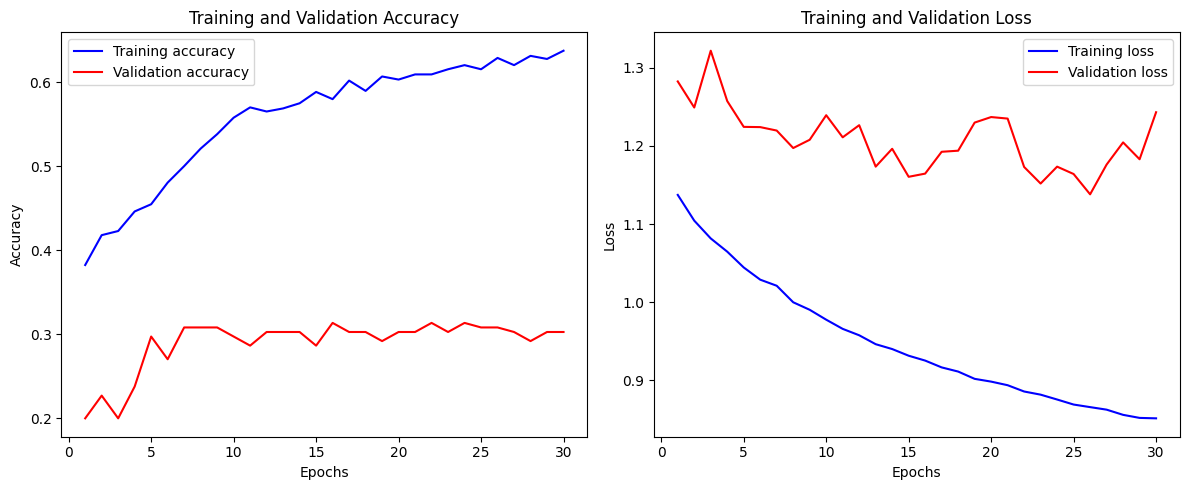

In [412]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_transfer_epochs_metrics_3.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [413]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_transfer_model3.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['手腕轉動時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3251

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.1667    0.0042    0.0083       236
     1分 (普通)     0.4730    0.4656    0.4693       320
      2分 (好)     0.2022    0.5515    0.2959       136

    accuracy                         0.3251       692
   macro avg     0.2806    0.3404    0.2578       692
weighted avg     0.3153    0.3251    0.2780       692



In [446]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/cnn_base_model4.keras")

cnn_transfer_model4 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in cnn_transfer_model4.layers:
    layer.trainable=False
cnn_transfer_model4.add(Dense(3, activation='softmax'))

cnn_transfer_model4.build(input_shape=old_model.input_shape)
cnn_transfer_model4.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_transfer_model4.summary()

Model: "sequential_98"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_34 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_34 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_24 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 1,827 (7.14 KB)

 Non-trainable params: 976 (3.81 KB)

In [447]:
cnn_transfer_epochs_metrics_4 = cnn_transfer_model4.fit(X_train_lift[train_indices[3]], y4[train_indices[3]],  validation_data=(X_train_lift[val_indices[3]], y4[val_indices[3]]), batch_size = 16, epochs = 25)

Epoch 1/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5179 - loss: 1.5178 - val_accuracy: 0.7059 - val_loss: 0.9678
Epoch 2/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5168 - loss: 1.0282 - val_accuracy: 0.7059 - val_loss: 0.8231
Epoch 3/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5237 - loss: 0.9839 - val_accuracy: 0.6912 - val_loss: 0.8425
Epoch 4/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5179 - loss: 0.9783 - val_accuracy: 0.7059 - val_loss: 0.8195
Epoch 5/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5214 - loss: 0.9748 - val_accuracy: 0.7059 - val_loss: 0.8059
Epoch 6/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5237 - loss: 0.9729 - val_accuracy: 0.6912 - val_loss: 0.8215
Epoch 7/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5179 - loss: 0.9662 - val_accuracy: 0.6985 - val_loss: 0.8273
Epoch 8/25
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5410 - loss: 0.9607 - val_accuracy: 0.7059 - val_loss:

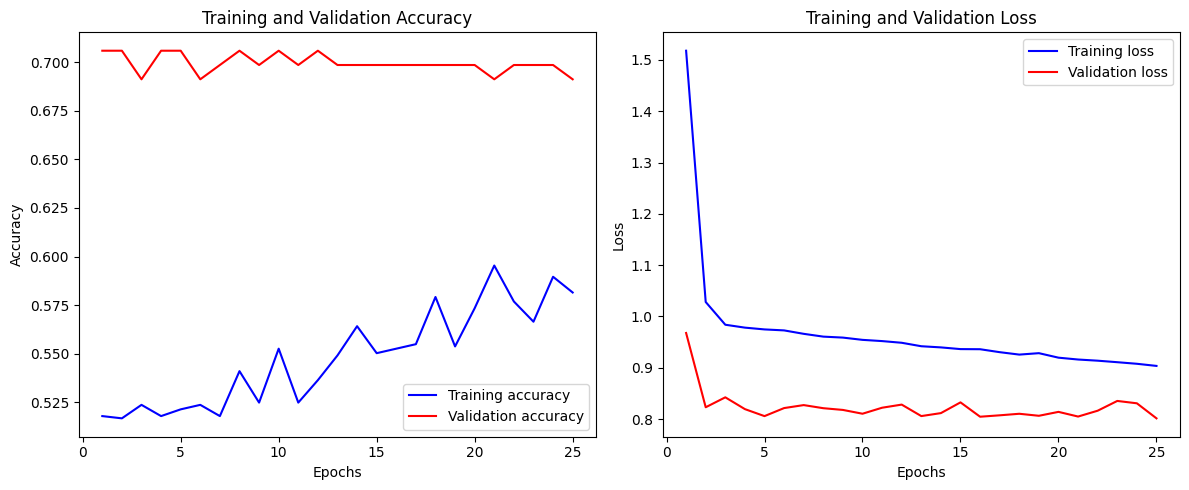

In [448]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_transfer_epochs_metrics_4.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [449]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_transfer_model4.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['擊球時機正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
整體測試集準確度 (Overall Test Accuracy): 0.5549

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000       109
     1分 (普通)     0.5837    0.9113    0.7116       417
      2分 (好)     0.0976    0.0241    0.0386       166

    accuracy                         0.5549       692
   macro avg     0.2271    0.3118    0.2501       692
weighted avg     0.3752    0.5549    0.4381       692



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [815]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense

old_model = load_model("models/cnn_base_model5.keras")

cnn_transfer_model5 = Sequential(old_model.layers[:-1])  # 移除最後一層
for layer in cnn_transfer_model5.layers:
    layer.trainable=False
cnn_transfer_model5.add(Dense(3, activation='softmax'))

cnn_transfer_model5.build(input_shape=old_model.input_shape)
cnn_transfer_model5.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_transfer_model5.summary()

Model: "sequential_196"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_35 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_35 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_25 (Flatten)            │ (None, 608)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_200 (Dense)               │ (None, 3)              │         1,827 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,803 (10.95 KB)

 Trainable params: 1,827 (7.14 KB)

 Non-trainable params: 976 (3.81 KB)

In [817]:
cnn_transfer_epochs_metrics_5 = cnn_transfer_model5.fit(X_train_lift[train_indices[4]], y5[train_indices[4]],  validation_data=(X_train_lift[val_indices[4]], y5[val_indices[4]]), batch_size = 16, epochs = 30)

Epoch 1/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.5199 - loss: 1.0242 - val_accuracy: 0.2238 - val_loss: 1.1934
Epoch 2/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.5262 - loss: 1.0133 - val_accuracy: 0.2238 - val_loss: 1.1858
Epoch 3/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5280 - loss: 1.0062 - val_accuracy: 0.2238 - val_loss: 1.1727
Epoch 4/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5280 - loss: 1.0023 - val_accuracy: 0.2238 - val_loss: 1.2278
Epoch 5/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5280 - loss: 0.9968 - val_accuracy: 0.2238 - val_loss: 1.1737
Epoch 6/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5298 - loss: 0.9942 - val_accuracy: 0.2286 - val_loss: 1.1726
Epoch 7/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5280 - loss: 0.9859 - val_accuracy: 0.2238 - val_loss: 1.2442
Epoch 8/30
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5271 - loss: 0.9827 - val_accuracy: 0.2238 - val_loss

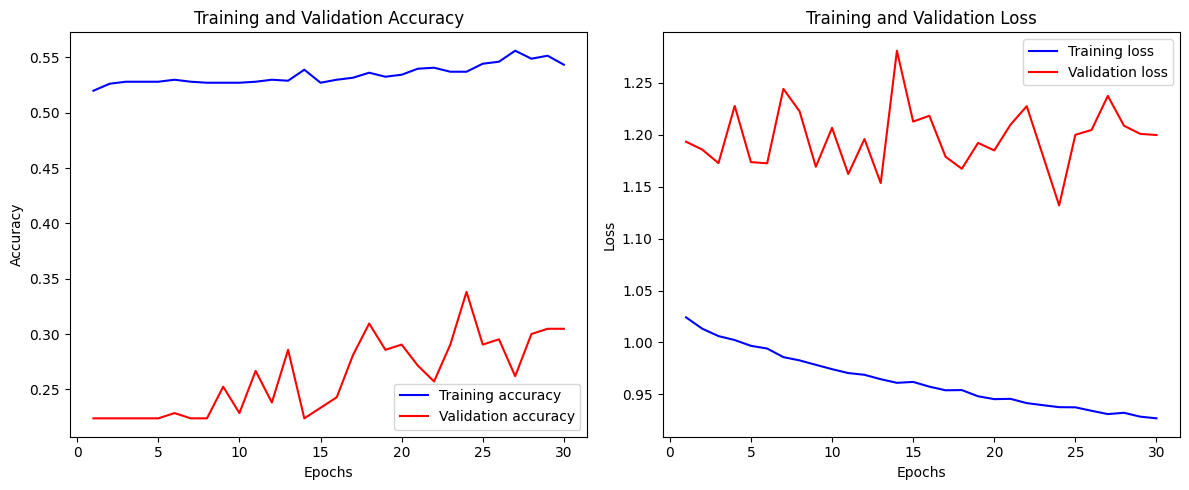

In [818]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_transfer_epochs_metrics_5.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [819]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_transfer_model5.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['擊球位置正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
整體測試集準確度 (Overall Test Accuracy): 0.3952

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        49
     1分 (普通)     0.3963    0.9933    0.5665       150
      2分 (好)     0.0000    0.0000    0.0000       178

    accuracy                         0.3952       377
   macro avg     0.1321    0.3311    0.1888       377
weighted avg     0.1577    0.3952    0.2254       377



c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\gordo\AI-badminton\badminton-venv\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

In [ ]:
from tensorflow.keras.models import load_model, Sequential
from tensorflow.keras.layers import Dense
import tensorflow as tf

# -------------------------------------------------
# 1. 載入舊模型 (高遠球)
# -------------------------------------------------
old_model = load_model("models/cnn_lstm_base_model1.keras")

cnn_lstm_transfer_model1 = Sequential()

for i in range(len(old_model.layers) - 1):   # 最後一層 Dense 不要複製
    cnn_lstm_transfer_model1.add(old_model.layers[i])


cnn_lstm_transfer_model1.add(Dense(3, activation='softmax'))


cnn_lstm_transfer_model1.layers[0].trainable = False

cnn_lstm_transfer_model1.layers[1].trainable = False

# LSTM 需要微調 → 不凍結
cnn_lstm_transfer_model1.layers[2].trainable = True

# Dropout 無參數 → 不影響
cnn_lstm_transfer_model1.layers[3].trainable = True

# 新 Dense → 必須訓練
cnn_lstm_transfer_model1.layers[4].trainable = True

cnn_lstm_transfer_model1.build(input_shape=old_model.input_shape)
# -------------------------------------------------
# 5. 重新編譯模型（LR 要小）
# -------------------------------------------------
cnn_lstm_transfer_model1.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_lstm_transfer_model1.summary()


Model: "sequential_206"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_39 (Conv1D)              │ (None, 116, 16)        │           976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_39 (MaxPooling1D) │ (None, 38, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_58 (LSTM)                  │ (None, 16)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_58 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_209 (Dense)               │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,139 (12.26 KB)

 Trainable params: 976 (3.81 KB)

 Non-trainable params: 2,163 (8.45 KB)

In [840]:
cnn_lstm_transfer_epochs_metrics_1 = cnn_lstm_transfer_model1.fit(X_train_lift[train_indices[0]], y1[train_indices[0]],  validation_data=(X_train_lift[val_indices[0]], y1[val_indices[0]]), batch_size = 16, epochs = 30)

Epoch 1/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.4030 - loss: 1.1538 - val_accuracy: 0.2787 - val_loss: 1.1239
Epoch 2/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4244 - loss: 1.1329 - val_accuracy: 0.2828 - val_loss: 1.1141
Epoch 3/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4263 - loss: 1.1351 - val_accuracy: 0.2828 - val_loss: 1.1126
Epoch 4/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4235 - loss: 1.1409 - val_accuracy: 0.2869 - val_loss: 1.1103
Epoch 5/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4263 - loss: 1.1396 - val_accuracy: 0.2951 - val_loss: 1.1071
Epoch 6/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.4151 - loss: 1.1371 - val_accuracy: 0.2828 - val_loss: 1.1143
Epoch 7/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4338 - loss: 1.1354 - val_accuracy: 0.2787 - val_loss: 1.1199
Epoch 8/30
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.4310 - loss: 1.1275 - val_accuracy: 0.2787 - v

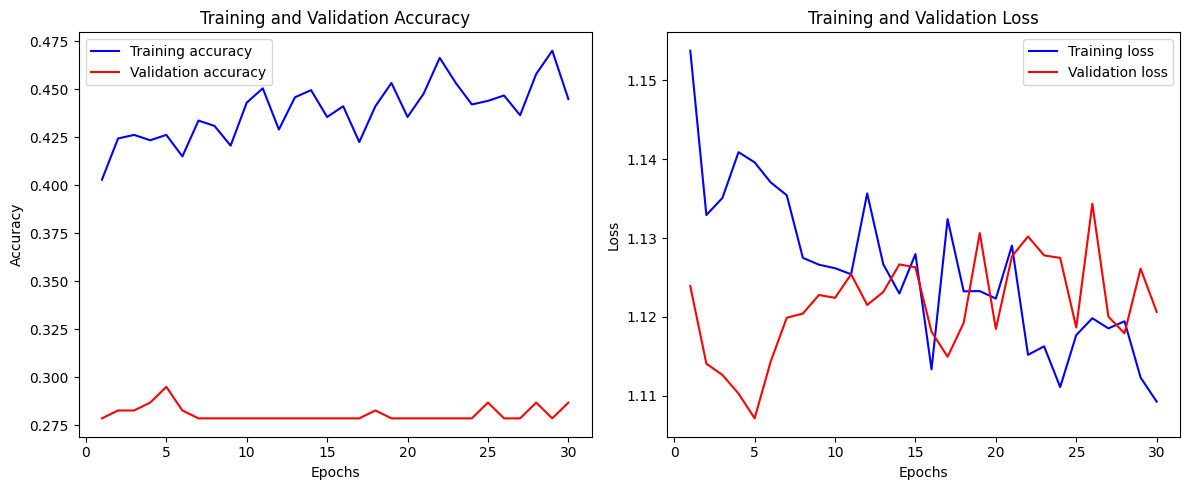

In [841]:
import matplotlib.pyplot as plt

# 獲取訓練記錄數據
history = cnn_lstm_transfer_epochs_metrics_1.history

# 獲取訓練的 epoch 數量
epochs = range(1, len(history['accuracy']) + 1)

## 1. 繪製 Accuracy (準確度) 圖
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1) # 設置第一個子圖
plt.plot(epochs, history['accuracy'], 'b', label='Training accuracy')
plt.plot(epochs, history['val_accuracy'], 'r', label='Validation accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

## 2. 繪製 Loss (損失) 圖
plt.subplot(1, 2, 2) # 設置第二個子圖
plt.plot(epochs, history['loss'], 'b', label='Training loss')
plt.plot(epochs, history['val_loss'], 'r', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout() # 自動調整子圖間距
plt.show()

In [843]:
import numpy as np
import pandas as pd # 確保已引入 pandas
from sklearn.metrics import classification_report, accuracy_score

# 假設 model1 是您訓練好的分類模型
# 假設 X_test_lift 已經準備好
# 假設 df_test_lift 是已經 reset_index(drop=True) 的測試集 DataFrame

# --------------------------------------------------
# 1. 預測：輸出機率分佈 (Softmax output)
# --------------------------------------------------
y_pred_proba = cnn_lstm_transfer_model1.predict(X_test_lift) 

# --------------------------------------------------
# 2. 獲取預測類別：找到機率最大的索引
# --------------------------------------------------
y_pred_classes = np.argmax(y_pred_proba, axis=1) 

# --------------------------------------------------
# 3. 獲取真實標籤：從 df_test_lift 中提取 "揮拍軌跡正確度"
# --------------------------------------------------
# 使用 .values 確保取出的是 NumPy array，並使用 .astype(int) 確保是整數
y_true = df_test_lift['揮拍軌跡正確度'].values.astype(int) 

# 打印整體準確度 (供參考)
test_accuracy = accuracy_score(y_true, y_pred_classes)
print(f"整體測試集準確度 (Overall Test Accuracy): {test_accuracy:.4f}")
print("\n" + "="*50)

# --------------------------------------------------
# 4. 打印分類報告
# --------------------------------------------------
print("詳細類別準確率報告 (Test Classification Report):")
print("-" * 50)
print(classification_report(
    y_true, 
    y_pred_classes, 
    target_names=['0分 (差)', '1分 (普通)', '2分 (好)'],
    digits=4 # 設置輸出精度
))
print("="*50)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
整體測試集準確度 (Overall Test Accuracy): 0.4536

詳細類別準確率報告 (Test Classification Report):
--------------------------------------------------
              precision    recall  f1-score   support

      0分 (差)     0.0000    0.0000    0.0000        17
     1分 (普通)     0.5422    0.2500    0.3422       180
      2分 (好)     0.4599    0.7000    0.5551       180

    accuracy                         0.4536       377
   macro avg     0.3340    0.3167    0.2991       377
weighted avg     0.4784    0.4536    0.4284       377

